# **British Airways Flight Booking Prediction**

Predicting customer booking behavior to enable proactive customer acquisition strategies.

Note: This is an updated version of the notebook, after using the knowledges that I got from several experiences.

# **STAGE 0: BUSINESS UNDERSTANDING**

## Problem Statement

British Airways faces challenges in customer acquisition, with traditional reactive approaches becoming less effective in today's digital marketplace. With customers having access to extensive information online, waiting for customers to make bookings at the airport is too late. The airline needs a proactive approach to identify and target potential customers before they make their travel decisions, requiring data-driven predictive capabilities to understand customer booking behavior in advance.

## Goals

- **Enhanced customer acquisition**: Develop machine learning models to predict customer booking likelihood, enabling proactive targeting of potential customers. (**MAIN**)
- **Improved business intelligence**: Understand factors influencing customer booking decisions to optimize marketing strategies. (**SECONDARY**)

## Business Metrics

| Metric | Description | Type |
|--------|-------------|------|
| **Customer Acquisition Rate** | The rate at which the airline acquires new customers who book flights or holidays | **MAIN** |
| **Model Predictive Power** | Evaluation metrics (accuracy, precision, recall) demonstrating the model's ability to identify potential customers | **MAIN** |

## Objectives

The ultimate goal of this project is to create a machine learning model that can:

- Accurately predict which customers are likely to book flights or holidays
- Identify key variables that influence booking decisions
- Provide actionable insights to improve customer acquisition strategies before customers embark on their holidays

# **STAGE 1: EXPLORATORY DATA ANALYSIS (EDA)**

## Project Setup

In [1]:
import os
import sys
from pathlib import Path

# Change working directory (for I/O operations)
os.chdir(Path.cwd())

In [2]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

# Settings
sns.set_style('darkgrid')
pd.set_option('display.max_columns', None)

## Data Understanding & Initial Transformation

In [3]:
# Read data
df_raw = pd.read_csv('data/customer_booking.csv', encoding='Latin1')

# Create a copy of the dataframe
df = df_raw.copy()

Let's first do a quick jump into something that quite interesting here that is the `route` and `booking_origin` columns. Because we can see that the `route` have AKLDEL which is Auckland - Delhi code but booking_origin which is their country could either be New Zealand or India, that means there could be 2 cases here: 

1. Passenger could be departing from their home country (booking_origin matches origin airport country)

2. Passenger returning to their home country (booking_origin matches destination airport country)

In [4]:
# Filter based on both route and booking_origin
df.loc[df['route'].isin(['AKLDEL', 'DELAKL'])]

,num_passengers,sales_channel,trip_type,purchase_lead,length_of_stay,flight_hour,flight_day,route,booking_origin,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete
0,2,Internet,RoundTrip,262,19,7,Sat,AKLDEL,New Zealand,1,0,0,5.52,0
1,1,Internet,RoundTrip,112,20,3,Sat,AKLDEL,New Zealand,0,0,0,5.52,0
2,2,Internet,RoundTrip,243,22,17,Wed,AKLDEL,India,1,1,0,5.52,0
3,1,Internet,RoundTrip,96,31,4,Sat,AKLDEL,New Zealand,0,0,1,5.52,0
4,2,Internet,RoundTrip,68,22,15,Wed,AKLDEL,India,1,0,1,5.52,0
5,1,Internet,RoundTrip,3,48,20,Thu,AKLDEL,New Zealand,1,0,1,5.52,0
6,3,Internet,RoundTrip,201,33,6,Thu,AKLDEL,New Zealand,1,0,1,5.52,0
7,2,Internet,RoundTrip,238,19,14,Mon,AKLDEL,India,1,0,1,5.52,0
8,1,Internet,RoundTrip,80,22,4,Mon,AKLDEL,New Zealand,0,0,1,5.52,0
9,1,Mobile,RoundTrip,378,30,12,Sun,AKLDEL,India,0,0,0,5.52,0


Turns out there is a new case which is the booking_origin country is United Kingdom. Since our knowledge about this dataset is very limited, it's hard to identify the source of this kind of anomaly, so for further in the project we would just go with assumption that the **booking_origin column means where the user did the transaction, they could be buying it for themself or for other like family member or something**. For now, we wont do much analysis that utilizes these 2 columns, so we will just extract the International Air Transport Association (IATA) code for now.

In [5]:
# Quick Feature Engineering: Extract airport codes from route
df['origin_airport'] = df['route'].str[:3]
df['destination_airport'] = df['route'].str[3:]

# Check the extracted codes
print("Origin airports:", df['origin_airport'].nunique())
print("Destination airports:", df['destination_airport'].nunique())

Origin airports: 85
Destination airports: 64


In [6]:
# Checking shape of dataframe
print(f'Number of rows: {df.shape[0]}')
print(f'Number of columns: {df.shape[1]}')

Number of rows: 50000
Number of columns: 16


In [7]:
# Check data information using utility function
from utils import check_data_information

info_df = check_data_information(df, df.columns.tolist())
display(info_df)

,Feature,Data Type,Null Values,Null Percentage,Zero Values,Zero Percentage,Negative Values,Negative Percentage,Empty Strings,Numeric in Object,Duplicated Values,Unique Values,Cardinality Ratio,Unique Sample
0,num_passengers,int64,0,0.0,0,0.00,0,0.0,0,0,719,9,0.0002,"2, 1, 3, 4, 6"
1,sales_channel,str,0,0.0,0,0.00,0,0.0,0,0,719,2,0.0000,"Internet, Mobile"
2,trip_type,str,0,0.0,0,0.00,0,0.0,0,0,719,3,0.0001,"RoundTrip, CircleTrip, OneWay"
3,purchase_lead,int64,0,0.0,370,0.74,0,0.0,0,0,719,470,0.0094,"262, 112, 243, 96, 68"
4,length_of_stay,int64,0,0.0,9,0.02,0,0.0,0,0,719,335,0.0067,"19, 20, 22, 31, 48"
5,flight_hour,int64,0,0.0,1539,3.08,0,0.0,0,0,719,24,0.0005,"7, 3, 17, 4, 15"
6,flight_day,str,0,0.0,0,0.00,0,0.0,0,0,719,7,0.0001,"Sat, Wed, Thu, Mon, Sun"
7,route,str,0,0.0,0,0.00,0,0.0,0,0,719,799,0.0160,"AKLDEL, AKLHGH, AKLHND, AKLICN, AKLKIX"
8,booking_origin,str,0,0.0,0,0.00,0,0.0,0,0,719,104,0.0021,"New Zealand, India, United Kingdom, China, Sou..."
9,wants_extra_baggage,int64,0,0.0,16561,33.12,0,0.0,0,0,719,2,0.0000,"1, 0"


In [8]:
# Drop duplicated values
df = df.drop_duplicates()
print(f'Rows after removing duplicates: {df.shape[0]}')

Rows after removing duplicates: 49281


### Feature Information - Flight Booking Dataset

| **Feature Name** | **Description** | **Data Type** | **Specific Data Type** |
|------------------|----------------|--------------|----------------------|
| `num_passengers` | Number of passengers travelling | Numerical | Discrete |
| `sales_channel` | Sales channel booking was made on (Internet, Mobile) | Categorical | Nominal |
| `trip_type` | Trip type (Round Trip, One Way, Circle Trip) | Categorical | Nominal |
| `purchase_lead` | Number of days between travel date and booking date | Numerical | Discrete |
| `length_of_stay` | Number of days spent at destination | Numerical | Discrete |
| `flight_hour` | Hour of flight departure | Numerical | Discrete |
| `flight_day` | Day of week of flight departure | Categorical | Nominal |
| `route` | Origin -> destination flight route | Categorical | Nominal |
| `booking_origin` | Country from where booking was made | Categorical | Nominal |
| `wants_extra_baggage` | If the customer wanted extra baggage (1=Yes, 0=No) | Categorical | Binary |
| `wants_preferred_seat` | If the customer wanted a preferred seat (1=Yes, 0=No) | Categorical | Binary |
| `wants_in_flight_meals` | If the customer wanted in-flight meals (1=Yes, 0=No) | Categorical | Binary |
| `flight_duration` | Total duration of flight (in hours) | Numerical | Continuous |
| `booking_complete` | Flag indicating if customer completed booking (1=Yes, 0=No) | Categorical | Binary |
| `origin_airport` | Airport code for departure location | Categorical | Nominal |
| `destination_airport` | Airport code for arrival location | Categorical | Nominal |

**Dataset Summary:**
- Total features: 16
- Target variable: `booking_complete` (binary classification target)
- Contains 640 null values (0.07% of the dataset)
- Dataset includes flight booking information with customer preferences, timing details, and route information
- Features include both numerical (discrete and continuous) and categorical variables

**Key Insights:**
- The dataset captures the entire booking journey from selection to completion
- Contains customer preference information (extra baggage, preferred seats, meals)
- Includes temporal data (purchase lead time, flight hour, day of week)
- Geographic information represented through routes and booking origin
- Binary target variable indicates whether bookings were completed or abandoned

In [9]:
# Change the data type for flight amenity preference columns (0 -> 'No', 1 -> 'Yes')
df['wants_extra_baggage'] = df['wants_extra_baggage'].map({0: 'No', 1: 'Yes'})
df['wants_preferred_seat'] = df['wants_preferred_seat'].map({0: 'No', 1: 'Yes'})
df['wants_in_flight_meals'] = df['wants_in_flight_meals'].map({0: 'No', 1: 'Yes'})

In [10]:
# Group columns by data type
nums_cols = ['num_passengers', 'purchase_lead', 'length_of_stay', 'flight_hour', 'flight_duration']
cats_cols = ['sales_channel', 'trip_type', 'flight_day', 'route', 'booking_origin', 
             'wants_extra_baggage', 'wants_preferred_seat', 'wants_in_flight_meals',
             'origin_airport', 'destination_airport']

target = "booking_complete"
target_label = "booking_complete_label"

In [11]:
# Create target label for visualization
df[target_label] = df[target].map({0: 'No Booking', 1: 'Completed Booking'})

## Univariate Analysis

**Purpose:** Understand distributions and basic statistics of features before splitting.

### Numerical Features

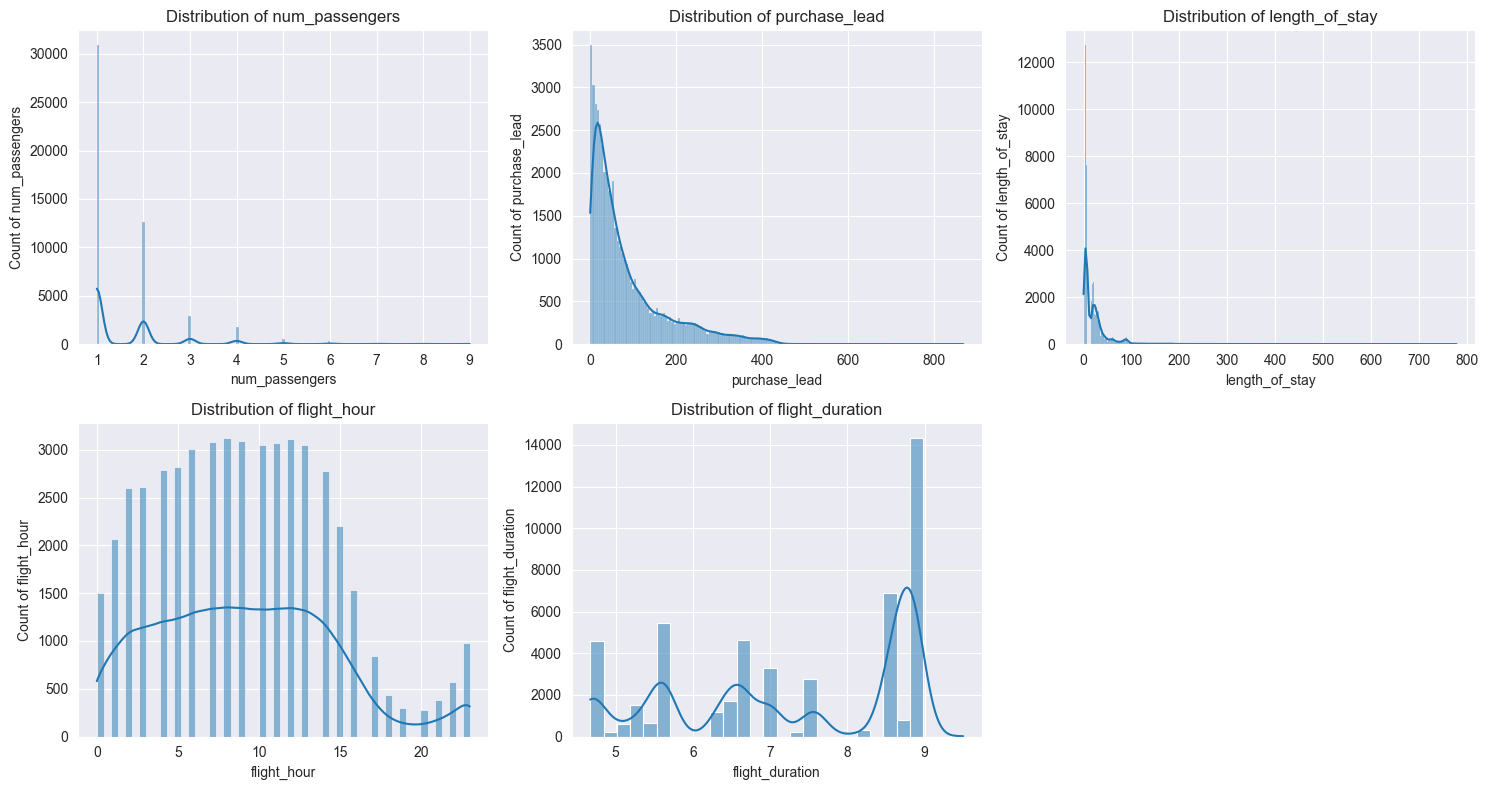

,Feature,overall_count,overall_mean,overall_std,overall_min,overall_25%,overall_50%,overall_75%,overall_max,overall_range,overall_IQR,overall_CV,overall_skewness,overall_kurtosis
0,num_passengers,49281.0,1.590187,1.016538,1.00,1.00,1.00,2.00,9.0,8.00,1.00,63.925663,2.688013,10.074914
1,purchase_lead,49281.0,84.723281,90.410229,0.00,21.00,51.00,115.00,867.0,867.00,94.00,106.712380,1.656766,2.501201
2,length_of_stay,49281.0,23.053976,33.832149,0.00,5.00,17.00,28.00,778.0,778.00,23.00,146.751906,5.296315,49.360070
3,flight_hour,49281.0,9.070676,5.413099,0.00,5.00,9.00,13.00,23.0,23.00,8.00,59.676906,0.398129,-0.299949
4,flight_duration,49281.0,7.279974,1.496390,4.67,5.62,7.57,8.83,9.5,4.83,3.21,20.554880,-0.362099,-1.372566


,Column Name,Mean,Median,Mode,Skewness,Kurtosis,Skewness Type,Kurtosis Type
0,num_passengers,1.590,1.00,1.00,2.688,10.075,Highly Positively Skewed,Leptokurtic (Heavy-tailed)
1,purchase_lead,84.723,51.00,1.00,1.657,2.501,Highly Positively Skewed,Leptokurtic (Heavy-tailed)
2,length_of_stay,23.054,17.00,6.00,5.296,49.360,Highly Positively Skewed,Leptokurtic (Heavy-tailed)
3,flight_hour,9.071,9.00,8.00,0.398,-0.300,Slightly Positively Skewed,Mesokurtic (Normal-like)
4,flight_duration,7.280,7.57,8.83,-0.362,-1.373,Slightly Negatively Skewed,Platykurtic (Light-tailed)
5,booking_complete,0.150,0.00,0.00,1.961,1.844,Highly Positively Skewed,Leptokurtic (Heavy-tailed)


In [12]:
# Checking the distribution and statistical summary of the numerical values
from utils import plot_dynamic_hisplots_kdeplots, describe_numerical_combined, identify_distribution_types

plot_dynamic_hisplots_kdeplots(df=df, col_series=nums_cols, ncols=3, figsize=(15, 8))

# Display the overall statistics for numerical columns
numerical_summary = describe_numerical_combined(df, nums_cols)
display(numerical_summary)

# Display the distribution types
result = identify_distribution_types(df, df.select_dtypes('number').columns.tolist())
display(result)

The distribution of several categorical features are bimodal, while for the `num_passengers`, `purchase_lead` and `lenght_of_stay` have positive/right skewed distribution, we will filter this whether using standarization or log transformation.

### Categorical Features

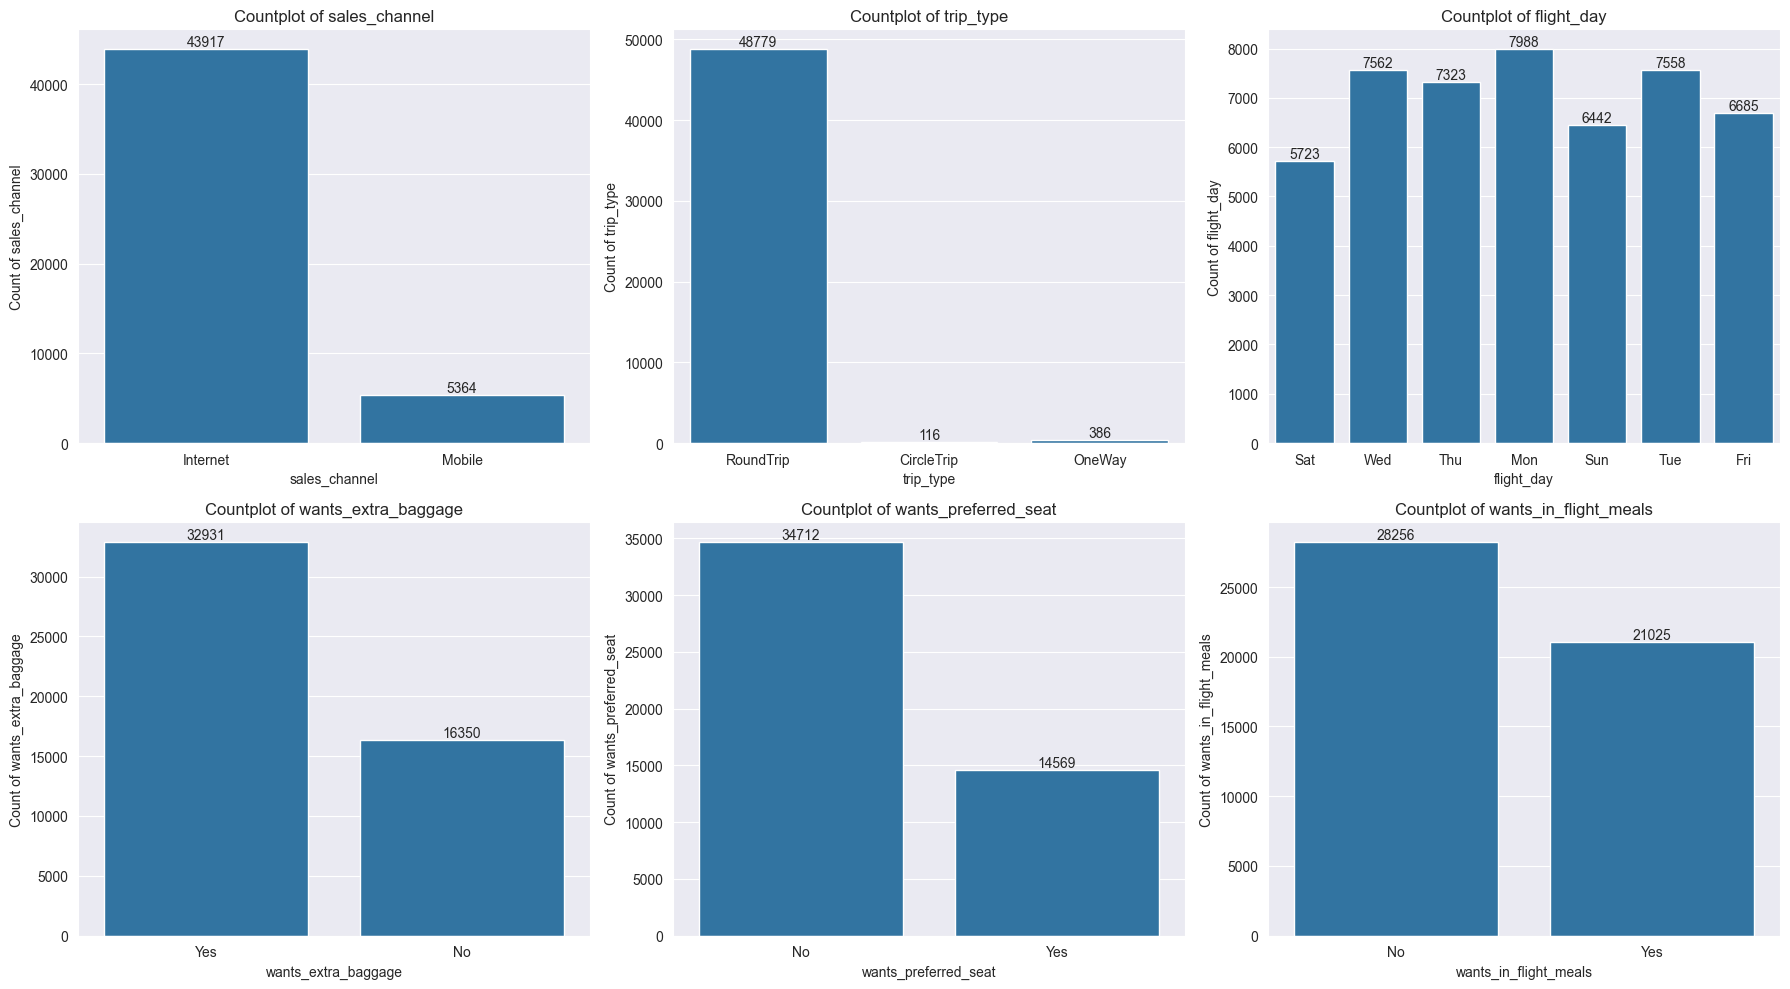

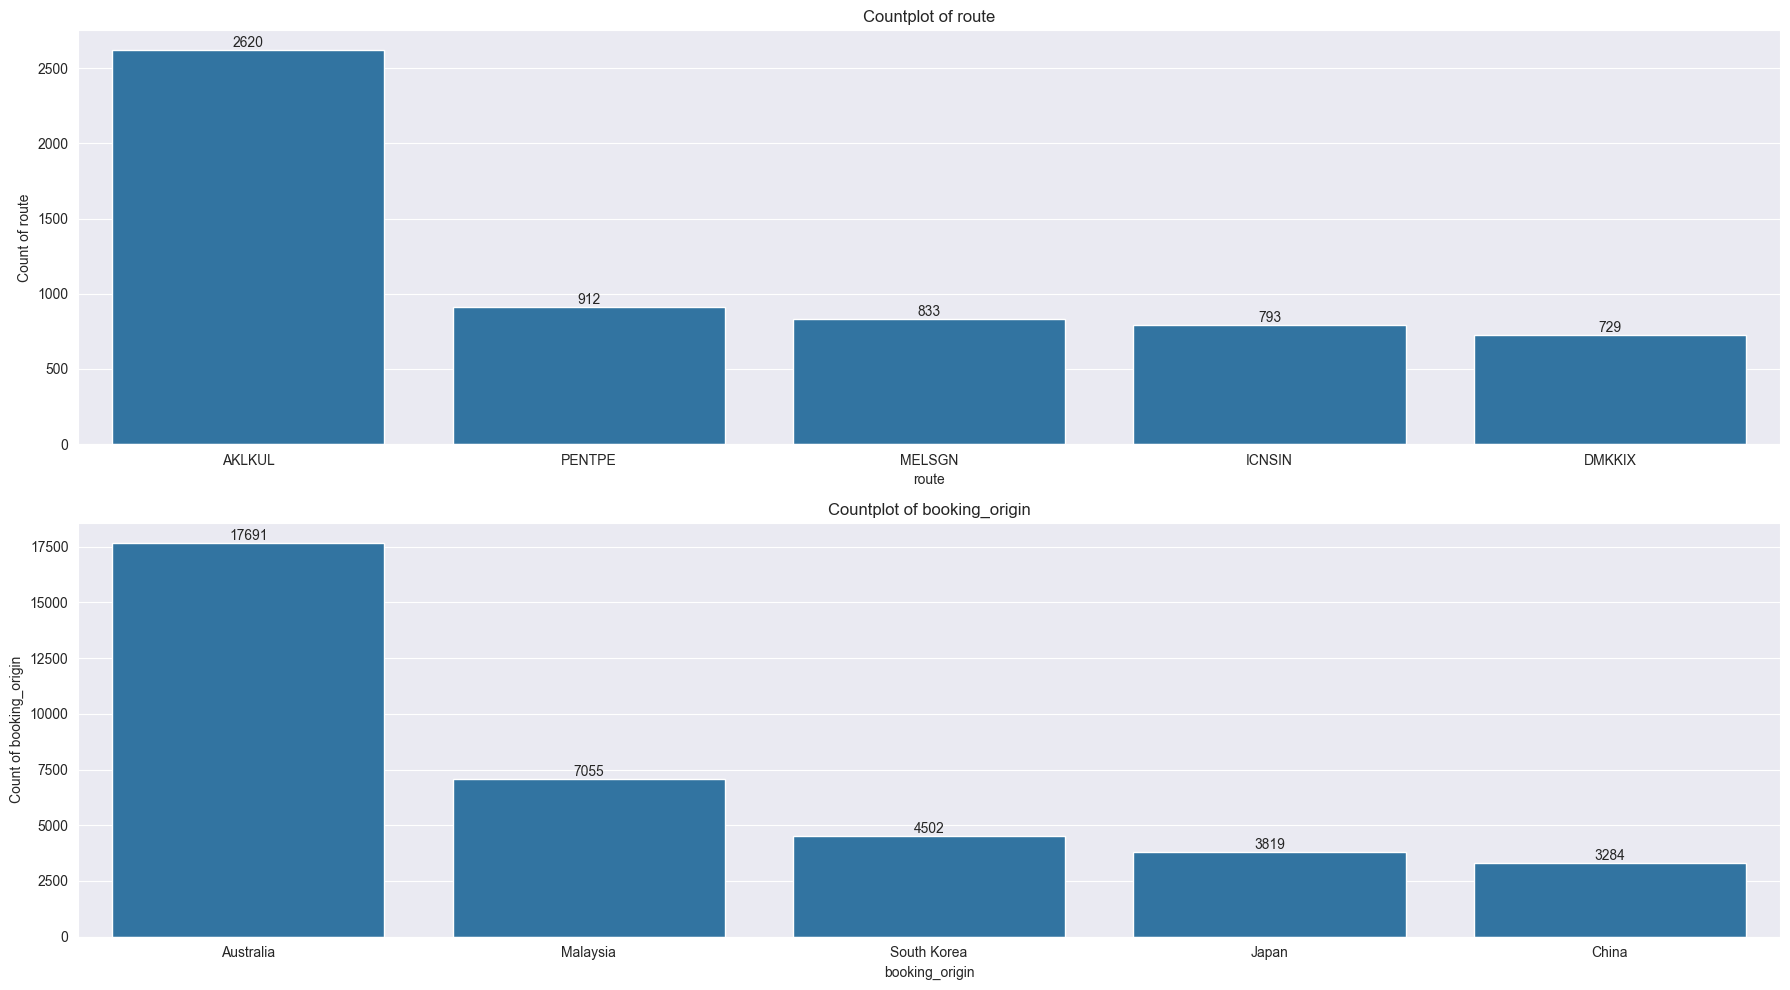

,Feature,overall_count,overall_unique,overall_top,overall_freq,overall_bottom,overall_freq_bottom,overall_top_percentage,overall_bottom_percentage,overall_n_categories
0,sales_channel,49281,2,Internet,43917,Mobile,5364,89.12,10.88,2
1,trip_type,49281,3,RoundTrip,48779,CircleTrip,116,98.98,0.24,3
2,flight_day,49281,7,Mon,7988,Sat,5723,16.21,11.61,7
3,route,49281,799,AKLKUL,2620,AKLHGH,1,5.32,0.00,799
4,booking_origin,49281,104,Australia,17691,Slovakia,1,35.90,0.00,104
5,wants_extra_baggage,49281,2,Yes,32931,No,16350,66.82,33.18,2
6,wants_preferred_seat,49281,2,No,34712,Yes,14569,70.44,29.56,2
7,wants_in_flight_meals,49281,2,No,28256,Yes,21025,57.34,42.66,2
8,origin_airport,49281,85,DMK,3698,BTJ,1,7.50,0.00,85
9,destination_airport,49281,64,SYD,6543,PDG,1,13.28,0.00,64


In [13]:
# Checking the distribution and statistical summary of categorical values
from utils import describe_categorical_combined, plot_dynamic_countplot

# Define categorical columns with few unique values for visualization
cats_few = ['sales_channel', 'trip_type', 'flight_day', 'wants_extra_baggage', 
            'wants_preferred_seat', 'wants_in_flight_meals']

# Define categorical columns with high cardinality categorical features (top 10 only)
cats_many = ['route', 'booking_origin']

plot_dynamic_countplot(df=df, col_series=cats_few, ncols=3, figsize=(18, 10))
plot_dynamic_countplot(df=df, col_series=cats_many, ncols=1, figsize=(18, 10),
     order=[df[cat].value_counts().iloc[:5].index.tolist() for cat in cats_many])

# Display statistics for categorical columns
categorical_summary = describe_categorical_combined(df, cats_cols)
display(categorical_summary)

### Target Distribution

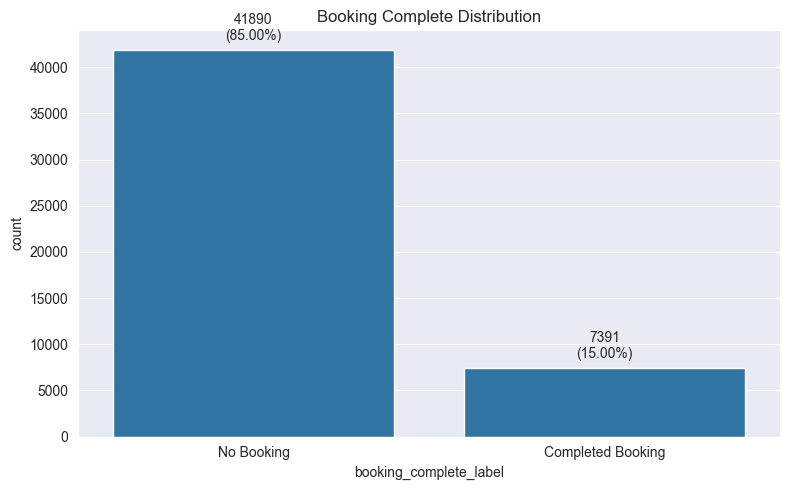


Class imbalance ratio: 5.67:1


In [14]:
# Visualize target distribution
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df, x=target_label)

total = len(df)
for p in ax.patches:
    count = p.get_height()
    percentage = 100 * count / total
    ax.annotate(f'{int(count)}\n({percentage:.2f}%)', 
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', xytext=(0, 5), textcoords='offset points')

plt.title('Booking Complete Distribution')
plt.tight_layout()
plt.show()

print(f"\nClass imbalance ratio: {df[target].value_counts()[0] / df[target].value_counts()[1]:.2f}:1")

- As we can that there is quite an class imbalance case here, where the values completed booking (1) only have 15.00 % of total dataset. So in this case we might use resampling method later, either with undersampling or oversampling with SMOTE.

- Note to remember that this is our main goal of this project which is trying to solve the small completed booking number by analyzing the customer booking history and create machine learning model to predict customer booking likelyhood for proactive marketing strategies. 

## Bivariate/Multivariate Analysis

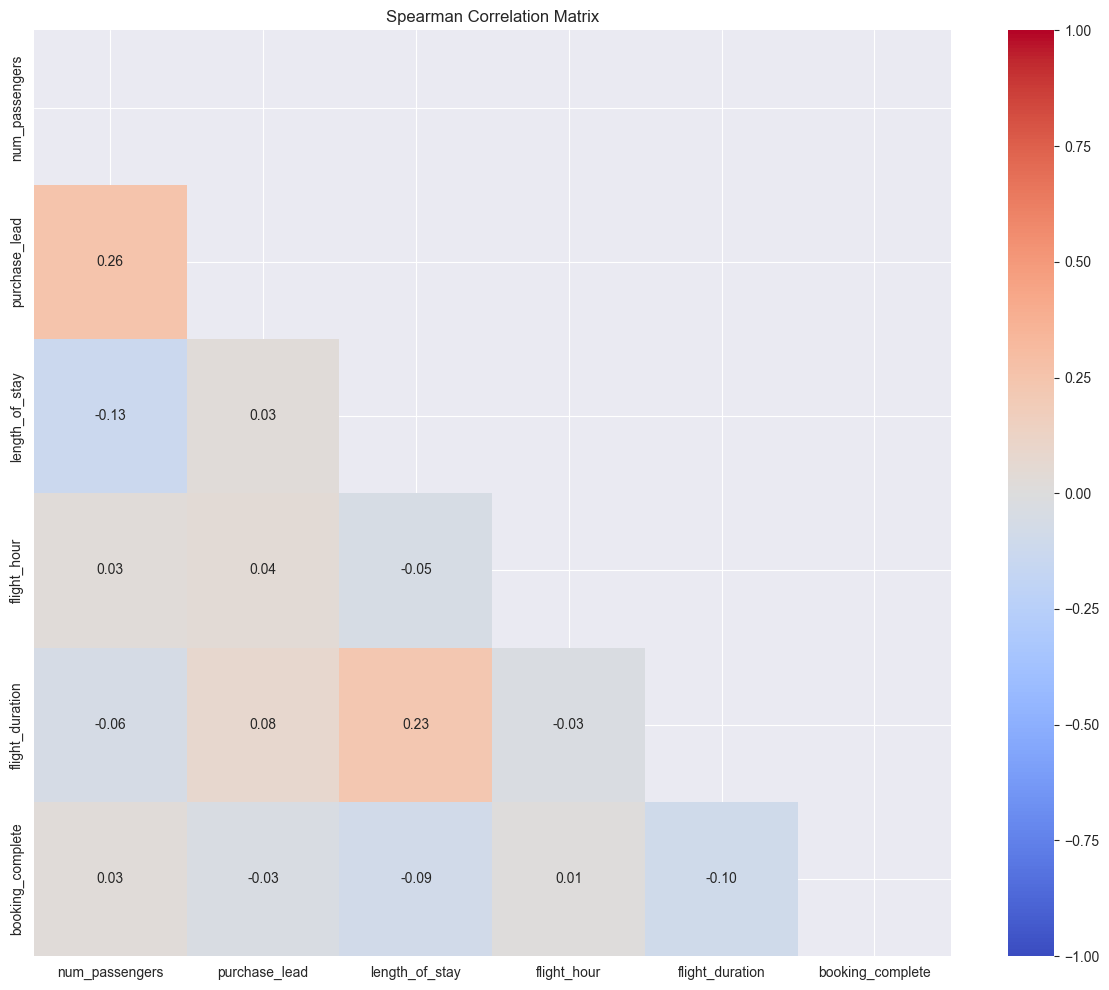

In [15]:
# Correlation heatmap of numerical features
plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(df[nums_cols + [target]].corr(method='spearman'), dtype=bool))
sns.heatmap(data=df[nums_cols + [target]].corr(method='spearman'), 
            mask=mask, cmap='coolwarm', annot=True, fmt='.2f', vmin=-1, vmax=1)
plt.title('Spearman Correlation Matrix')
plt.tight_layout()
plt.show()

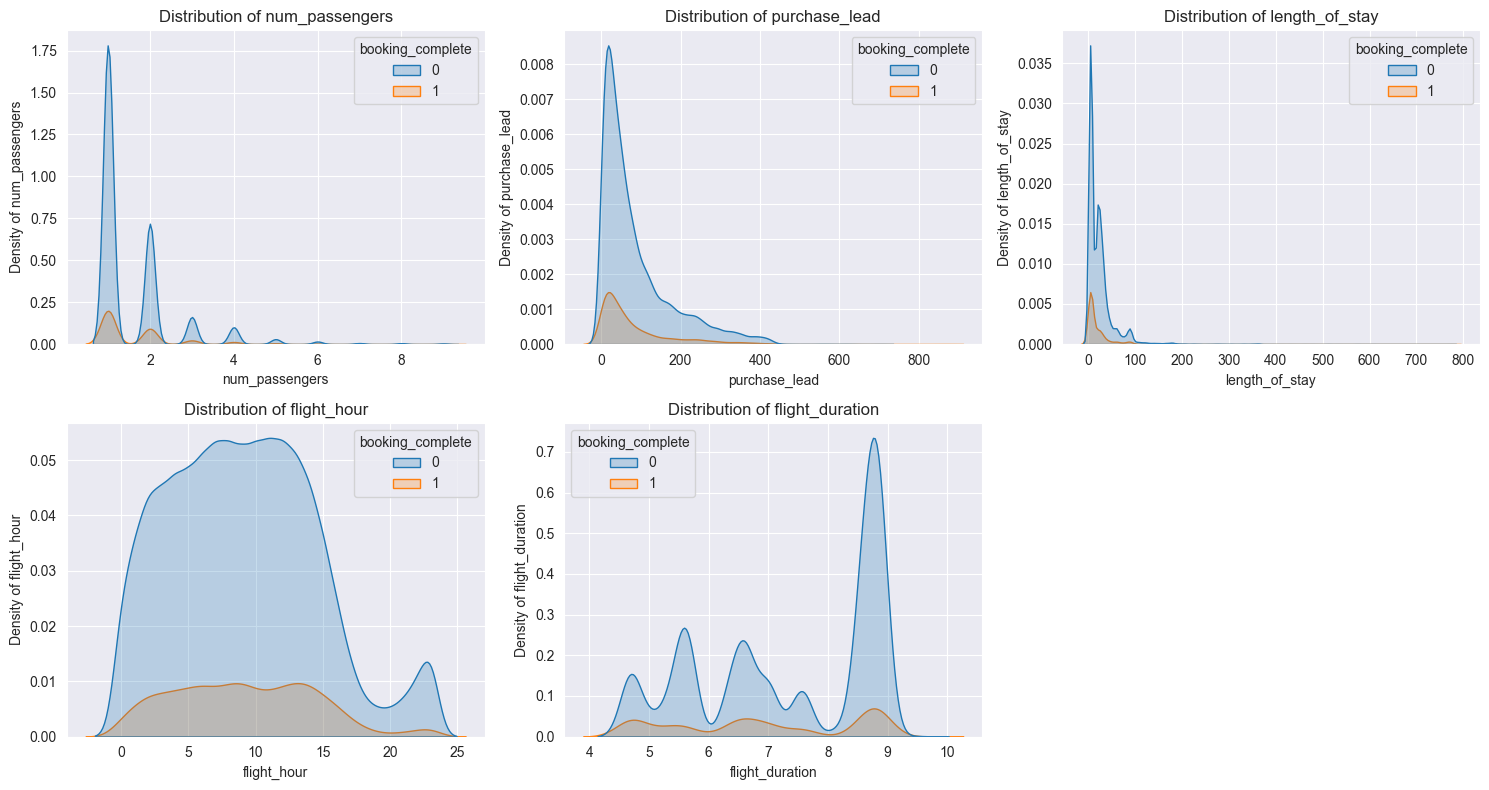

In [16]:
# Kdeplot with hue booking_complete
plot_dynamic_hisplots_kdeplots(df=df, col_series=nums_cols, ncols=3, plot_type='kdeplot', hue='booking_complete', figsize=(15, 8), fill=True)

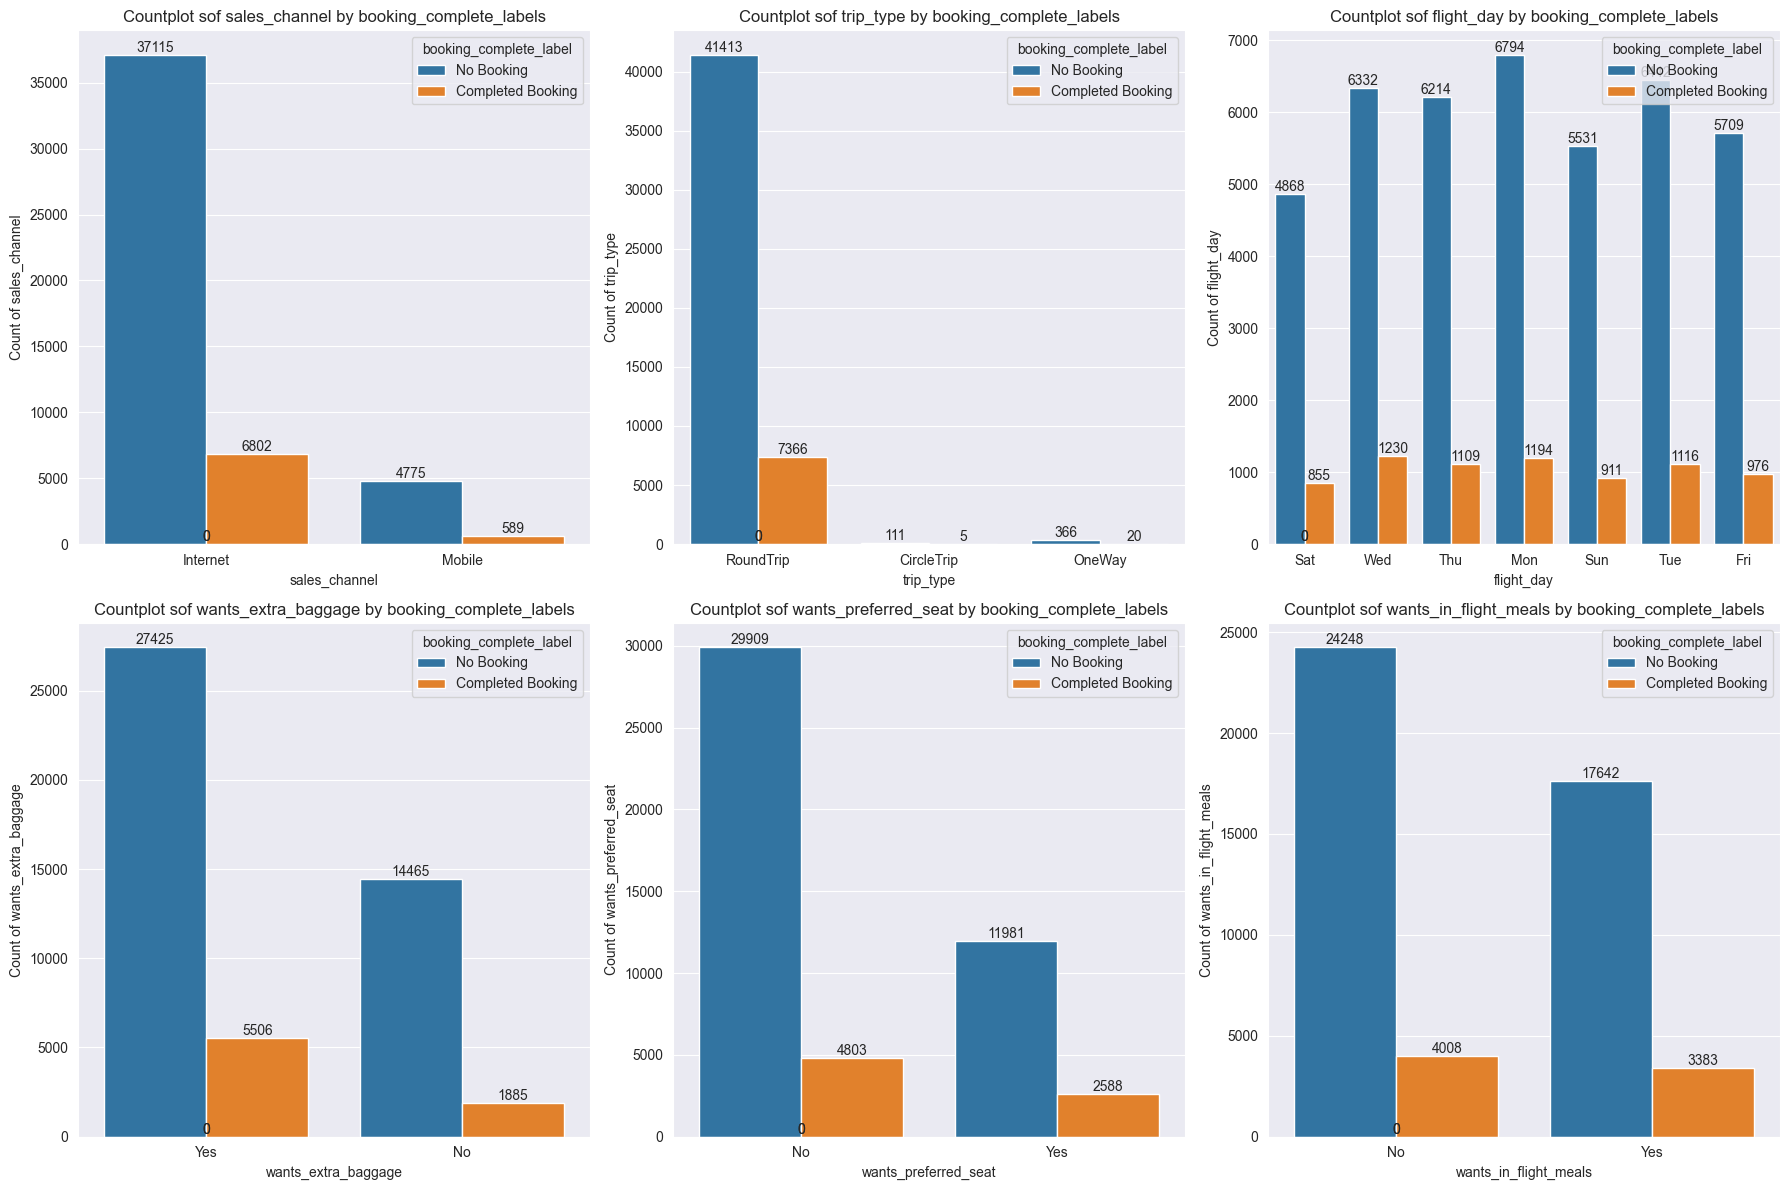

In [17]:
# Countplot with hue for categorical features vs target
plot_dynamic_countplot(df=df, col_series=cats_few, ncols=3, hue=target_label, figsize=(18, 12)) # use stacked=True if necessary

# **STAGE 2: DATA SPLITTING (CRITICAL STEP)**

**Splitting BEFORE preprocessing prevents data leakage:**

1. **Outlier Removal:** If we calculate IQR on full dataset, test set statistics influence training decisions
2. **Feature Encoding:** Category frequencies from test set shouldn't inform training
3. **Feature Selection:** Correlation/importance scores using test data = cheating
4. **Scaling:** Must come after split, fitted on training data only

**Principle:** Test set should be completely unseen until final evaluation.

## Split Strategy: 75% Train, 20% Validation, 5% Test

- **Training (75%):** Fit all preprocessing steps and train models
- **Validation (20%):** Tune hyperparameters and select best model
- **Test (5%):** Final evaluation only, never touched during development

**Note:** We use stratified sampling to preserve the class imbalance ratio across all splits.

In [64]:
from sklearn.model_selection import train_test_split

# Drop derived columns not needed for modeling
cols_to_drop = ['origin_airport', 'destination_airport', target_label]

# Separate features and target
X_raw = df.drop(columns=[target] + cols_to_drop)
y_raw = df[target]

# First split: 75% train, 25% temp (which will become val + test)
X_train_raw, X_temp_raw, y_train_raw, y_temp_raw = train_test_split(
    X_raw, y_raw, 
    test_size=0.25, 
    random_state=42,
    stratify=y_raw  # Preserve class imbalance
)

# Second split: Split temp into 80% validation (20% of original) and 20% test (5% of original)
X_val_raw, X_test_raw, y_val_raw, y_test_raw = train_test_split(
    X_temp_raw, y_temp_raw, 
    test_size=0.2, 
    random_state=42,
    stratify=y_temp_raw
)

# Display split sizes
total_samples = len(X_raw)
print(f"Total samples: {total_samples:,}")
print(f"\nTraining set: {len(X_train_raw):,} samples ({len(X_train_raw)/total_samples*100:.1f}%)")
print(f"Validation set: {len(X_val_raw):,} samples ({len(X_val_raw)/total_samples*100:.1f}%)")
print(f"Test set: {len(X_test_raw):,} samples ({len(X_test_raw)/total_samples*100:.1f}%)")

# Check target distribution across splits
print(f"\nTarget distribution in Training set:")
print(y_train_raw.value_counts(normalize=True))
print(f"\nTarget distribution in Validation set:")
print(y_val_raw.value_counts(normalize=True))
print(f"\nTarget distribution in Test set:")
print(y_test_raw.value_counts(normalize=True))

# Save RAW test set immediately (before any preprocessing)
# This is what we'll use for final inference in the Streamlit app
df_test_raw = pd.concat([X_test_raw.reset_index(drop=True), y_test_raw.reset_index(drop=True)], axis=1)
df_test_raw.to_csv('data/test_data_5%_raw.csv', index=False)
print(f"\nRaw test data saved to: data/test_data_5%_raw.csv")
print("⚠️ This file contains UNPROCESSED test data for inference.")

Total samples: 49,281

Training set: 36,960 samples (75.0%)
Validation set: 9,856 samples (20.0%)
Test set: 2,465 samples (5.0%)

Target distribution in Training set:
booking_complete
0    0.850027
1    0.149973
Name: proportion, dtype: float64

Target distribution in Validation set:
booking_complete
0    0.850041
1    0.149959
Name: proportion, dtype: float64

Target distribution in Test set:
booking_complete
0    0.849899
1    0.150101
Name: proportion, dtype: float64

Raw test data saved to: data/test_data_5%_raw.csv
⚠️ This file contains UNPROCESSED test data for inference.


# **STAGE 3: DATA PREPROCESSING (TRAIN + VAL ONLY)**

From this point forward:
- All preprocessing is **fitted on training data only**
- Validation and test sets are **transformed** using training statistics
- We never look at test set until final evaluation

## Outlier Detection and Removal

**Why after split?** IQR thresholds calculated from training data only.

Amount of Rows: 36960
Amount of Outlier Rows (Across All Columns): 10231
Amount of Non-Outlier Rows (Across All Columns): 26729
Percentage of Outliers: 27.68%



,Column Name,Outlier Exist,Lower Limit,Upper Limit,Outlier Data,Non-Outlier Data,Outlier Percentage (%)
0,num_passengers,True,0.00,3.00,2149,34811,5.81
1,purchase_lead,True,-73.00,209.00,4191,32769,11.34
2,length_of_stay,True,-18.00,51.00,3793,33167,10.26
3,flight_hour,True,-3.00,21.00,1165,35795,3.15
4,flight_duration,False,2.41,12.04,0,36960,0.00


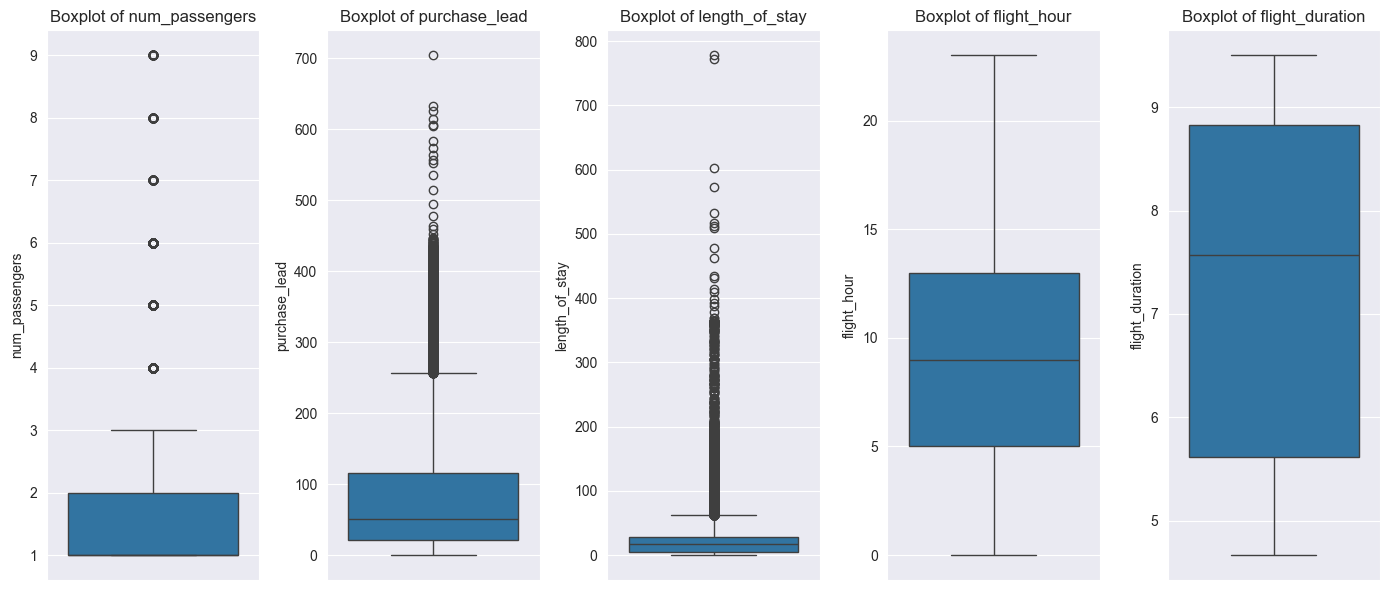

In [19]:
from utils import filter_outliers, plot_dynamic_boxplots_violinplots

# Combine train features and target for outlier detection
df_train = pd.concat([X_train_raw, y_train_raw], axis=1)

# Check outliers on TRAINING data only
outlier_summary = filter_outliers(df_train, columns=nums_cols, threshold=1, detect_only=True)
display(outlier_summary)

# Visualize outliers in training data
plot_dynamic_boxplots_violinplots(df_train, [col for col in nums_cols if col != "booking_complete"], plot_type="boxplot", ncols=5, orientation="v", figsize=(14, 6))

In [20]:
# Remove outliers from TRAINING data and get IQR limits
# Step 1: Get IQR limits from training data
train_outlier_summary = filter_outliers(df_train, columns=nums_cols, method='iqr', threshold=1, detect_only=True, verbose=False)

# Step 2: Remove outliers from training data
df_train_clean = filter_outliers(df_train, columns=nums_cols, method='iqr', threshold=1, detect_only=False)
X_train_clean = df_train_clean.drop(columns=[target])
y_train_clean = df_train_clean[target]

# Step 3: Apply SAME IQR limits to validation data
def filter_using_training_limits(data, columns, limits_df):
    """Filter outliers using pre-computed IQR limits from training data."""
    mask = pd.Series([True] * len(data), index=data.index)
    
    for _, row in limits_df.iterrows():
        col = row['Column Name']
        if col in columns and col in data.columns:
            lower = row['Lower Limit']
            upper = row['Upper Limit']
            col_mask = (data[col] >= lower) & (data[col] <= upper)
            mask = mask & col_mask
    
    return data[mask]

# Apply to validation
df_val = pd.concat([X_val_raw, y_val_raw], axis=1)
df_val_clean = filter_using_training_limits(df_val, nums_cols, train_outlier_summary)
X_val_clean = df_val_clean.drop(columns=[target])
y_val_clean = df_val_clean[target]

print(f"Training samples after outlier removal: {len(X_train_clean):,}")
print(f"Removed {len(X_train_raw) - len(X_train_clean):,} outlier samples from training set")
print(f"\nValidation samples after applying training limits: {len(X_val_clean):,}")
print(f"Removed {len(X_val_raw) - len(X_val_clean):,} outlier samples from validation set")
print(f"\nTest set: {len(X_test_raw):,} (unchanged - for final evaluation only)")

Training samples after outlier removal: 26,729
Removed 10,231 outlier samples from training set

Validation samples after applying training limits: 7,181
Removed 2,675 outlier samples from validation set

Test set: 2,465 (unchanged - for final evaluation only)


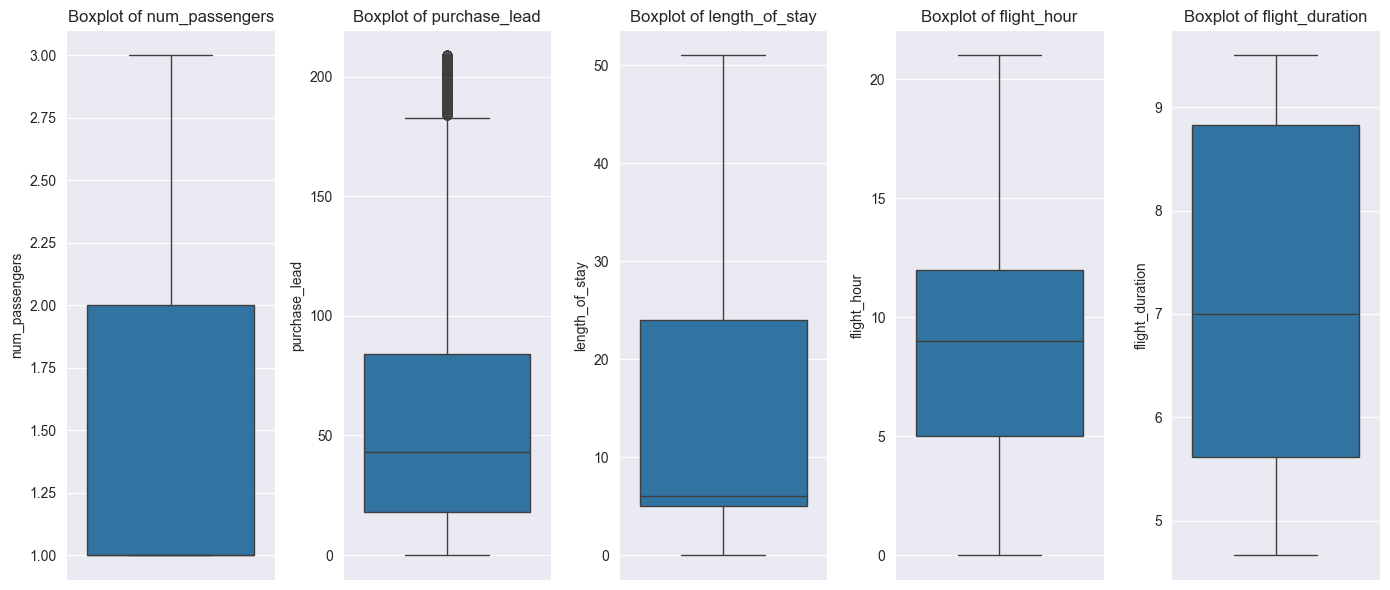

In [21]:
# Re-check outliers after handling
plot_dynamic_boxplots_violinplots(df_train_clean, [col for col in nums_cols if col != "booking_complete"], plot_type="boxplot", ncols=5, orientation="v", figsize=(14, 6))

## Feature Encoding

**Encoding Strategy:**
- **Label Encoding:** For binary features (sales_channel)
- **Frequency Encoding:** For high cardinality features (route, booking_origin)
- **One-Hot Encoding:** For nominal categories with low cardinality (trip_type, flight_day)

In [22]:
from utils import feature_encoding

# Make copies for encoding
X_train_encoded = X_train_clean.copy()
X_val_encoded = X_val_clean.copy()
X_test_encoded = X_test_raw.copy()

# Convert flight amenity preference columns back to integer form ('No' -> 0, 'Yes' -> 1)
for col in ['wants_extra_baggage', 'wants_preferred_seat', 'wants_in_flight_meals']:
    X_train_encoded[col] = X_train_encoded[col].map({'No': 0, 'Yes': 1}).astype(int)
    X_val_encoded[col] = X_val_encoded[col].map({'No': 0, 'Yes': 1}).astype(int)
    X_test_encoded[col] = X_test_encoded[col].map({'No': 0, 'Yes': 1}).astype(int)

# Define categorical columns for feature encoding
binary_cols = ['sales_channel']
frequency_cols = ['route', 'booking_origin']
ohe_cols = ['trip_type', 'flight_day']

# Fit on training data
X_train_encoded, encoders = feature_encoding(
    X_train_encoded,
    binary_columns=binary_cols,           # Label encode binary
    frequency_columns=frequency_cols,  # Frequency encode
    nominal_columns=ohe_cols,
)

# Transform validation data (reuses fitted encoders)
X_val_encoded, _ = feature_encoding(
    X_val_encoded,
    binary_columns=binary_cols,
    frequency_columns=frequency_cols,
    nominal_columns=ohe_cols,
    encoders=encoders  # Reuse fitted encoders
)

# Transform test data (reuses fitted encoders)
X_test_encoded, _ = feature_encoding(
    X_test_encoded,
    binary_columns=binary_cols,
    frequency_columns=frequency_cols,
    nominal_columns=ohe_cols,
    encoders=encoders  # Reuse fitted encoders
)

print(f"Encoded features shape: {X_train_encoded.shape}")
print(f"\nFeature columns after encoding:")
print(X_train_encoded.columns.tolist())
print("Re-check the final encoded dataframe:")
display(X_train_encoded.head(3))

Encoded features shape: (26729, 19)

Feature columns after encoding:
['trip_type_OneWay', 'trip_type_RoundTrip', 'flight_day_Mon', 'flight_day_Sat', 'flight_day_Sun', 'flight_day_Thu', 'flight_day_Tue', 'flight_day_Wed', 'num_passengers', 'sales_channel', 'purchase_lead', 'length_of_stay', 'flight_hour', 'route', 'booking_origin', 'wants_extra_baggage', 'wants_preferred_seat', 'wants_in_flight_meals', 'flight_duration']
Re-check the final encoded dataframe:


,trip_type_OneWay,trip_type_RoundTrip,flight_day_Mon,flight_day_Sat,flight_day_Sun,flight_day_Thu,flight_day_Tue,flight_day_Wed,num_passengers,sales_channel,purchase_lead,length_of_stay,flight_hour,route,booking_origin,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration
41143,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1,0,11,5,6,11,9814,0,0,1,8.83
9792,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1,0,48,22,2,409,9814,0,0,0,5.62
28455,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1,0,6,3,7,43,2266,0,0,0,7.00


## Feature Selection

In [23]:
from utils import calculate_correlation_tabular

# Combine train data for correlation analysis
df_train_encoded = pd.concat([X_train_encoded, y_train_clean.reset_index(drop=True)], axis=1)

# Calculate correlation on TRAINING data only
feature_feature_df, feature_target_df = calculate_correlation_tabular(
    df_train_encoded, 
    target_col=target, 
    method='spearman', 
    corr_type='both'
)

Correlation Between Features:


,A,B,Corr Value,Corr Type
0,trip_type_OneWay,trip_type_RoundTrip,0.895099,Negative
1,wants_preferred_seat,wants_in_flight_meals,0.313934,Positive
2,booking_origin,flight_duration,0.297970,Positive
3,length_of_stay,wants_extra_baggage,0.273476,Positive
4,booking_origin,length_of_stay,0.225690,Positive
5,flight_duration,length_of_stay,0.222064,Positive
6,wants_extra_baggage,wants_preferred_seat,0.207480,Positive
7,wants_in_flight_meals,wants_extra_baggage,0.203839,Positive
8,num_passengers,purchase_lead,0.197228,Positive
9,flight_day_Mon,flight_day_Wed,0.186110,Negative



Correlation of Features to Target:


,Feature,Corr Value,Corr Type
0,wants_extra_baggage,0.013677,Positive
1,flight_day_Thu,0.013521,Negative
2,flight_day_Sat,0.011753,Positive
3,wants_preferred_seat,0.009515,Positive
4,wants_in_flight_meals,0.008619,Positive
5,trip_type_OneWay,0.007732,Positive
6,sales_channel,0.006182,Negative
7,trip_type_RoundTrip,0.005394,Negative
8,flight_day_Wed,0.003951,Negative
9,flight_hour,0.003116,Positive


In [24]:
from utils import calculate_feature_importance

# Calculate feature importance using TRAINING data only
feature_importance_f = calculate_feature_importance(
    X=X_train_encoded, 
    y=y_train_clean.reset_index(drop=True), 
    task='classification', 
    method='anova', 
    k='all'
)

print("Feature importance (F-classif, top 15):")
display(feature_importance_f.iloc[:15].reset_index(drop=True))

Feature importance (F-classif, top 15):


,Feature,Score,P_Values
0,booking_origin,1081.040493,1.868253e-232
1,length_of_stay,312.591441,1.482860e-69
2,flight_duration,299.619428,9.227440e-67
3,wants_extra_baggage,110.482448,8.626428e-26
4,wants_preferred_seat,69.972321,6.303771e-17
5,sales_channel,60.790236,6.579584e-15
6,route,41.263125,1.352925e-10
7,purchase_lead,31.911608,1.629891e-08
8,trip_type_RoundTrip,22.419434,2.202683e-06
9,wants_in_flight_meals,20.690239,5.422765e-06


In [25]:
from utils import calculate_feature_importance

# Calculate feature importance using TRAINING data only
feature_importance = calculate_feature_importance(
    X=X_train_encoded, 
    y=y_train_clean.reset_index(drop=True), 
    task='classification', 
    method='mutual_info', 
    k='all'
)

print("Top 15 features by Mutual Information:")
display(feature_importance.head(15))

Top 15 features by Mutual Information:


,Feature,Score,P_Values
14,booking_origin,0.051692,None
13,route,0.035573,None
18,flight_duration,0.016404,None
11,length_of_stay,0.008640,None
1,trip_type_RoundTrip,0.003954,None
17,wants_in_flight_meals,0.003699,None
12,flight_hour,0.003525,None
15,wants_extra_baggage,0.003326,None
10,purchase_lead,0.002061,None
5,flight_day_Thu,0.001948,None



Chi-Square Analysis Results:
--------------------------------------------------------------------------------


,Feature,Chi-Square,P-Value,Cramér's V,Effect Size,Is Significant,Strongest Category,Association Direction
14,booking_origin,2699.005768,0.000000e+00,0.317768,Medium,True,3448.00,Positive
13,route,1986.090767,0.000000e+00,0.272589,Small,True,557.00,Positive
18,flight_duration,884.307011,1.715843e-174,0.181891,Small,True,8.58,Negative
11,length_of_stay,470.749549,2.147016e-74,0.132710,Small,True,6.00,Positive
10,purchase_lead,231.637994,1.352388e-01,0.093092,Negligible,False,69.00,Negative
15,wants_extra_baggage,109.662724,1.161659e-25,0.064053,Negligible,True,0.00,Negative
16,wants_preferred_seat,69.481119,7.714953e-17,0.050985,Negligible,True,1.00,Positive
12,flight_hour,61.443761,7.703192e-06,0.047945,Negligible,True,17.00,Positive
9,sales_channel,60.243282,8.382845e-15,0.047475,Negligible,True,1.00,Negative
1,trip_type_RoundTrip,21.614121,3.333882e-06,0.028437,Negligible,True,0.00,Negative


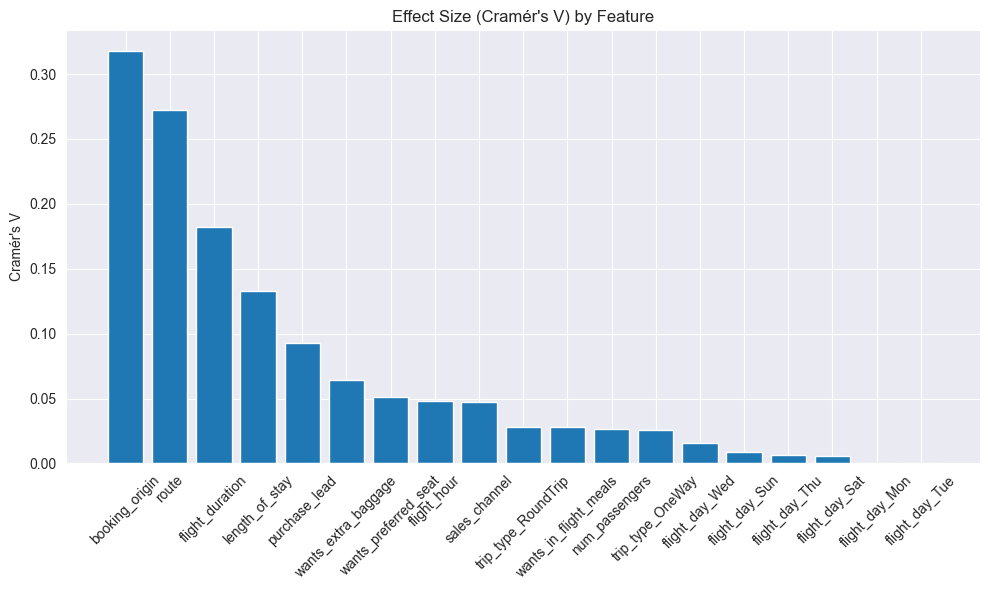

In [26]:
# Categorical features correlation analysis
from utils import analyze_categorical_relationships

# Temporary combine train features and target
df_train_encoded = pd.concat([X_train_encoded, y_train_clean], axis=1)

# Analyze relationships between categorical features and target
results = analyze_categorical_relationships(
    df_train_encoded, 
    features=[col for col in df_train_encoded if col != "booking_complete"], 
    target="booking_complete", 
    alpha=0.05
)

In [27]:
# Select features based on training data analysis 
base_cols = ["booking_origin", "route", "flight_duration", "length_of_stay",
       "sales_channel", "purchase_lead", "wants_extra_baggage", "wants_preferred_seat",
       "wants_in_flight_meals", "num_passengers"]
       
trip_type_cols = [col for col in X_train_encoded.columns if col.startswith("trip_type_")]
selected_cols = base_cols + trip_type_cols

# Apply feature selection to all sets
X_train_selected = X_train_encoded[selected_cols]
X_val_selected = X_val_encoded[selected_cols]
X_test_selected = X_test_encoded[selected_cols]

print(f"Selected {len(selected_cols)} features for modeling")
print(f"\nTraining set: {X_train_selected.shape}")
print(f"Validation set: {X_val_selected.shape}")
print(f"Test set: {X_test_selected.shape}")

Selected 12 features for modeling

Training set: (26729, 12)
Validation set: (7181, 12)
Test set: (2465, 12)


## Feature Scaling

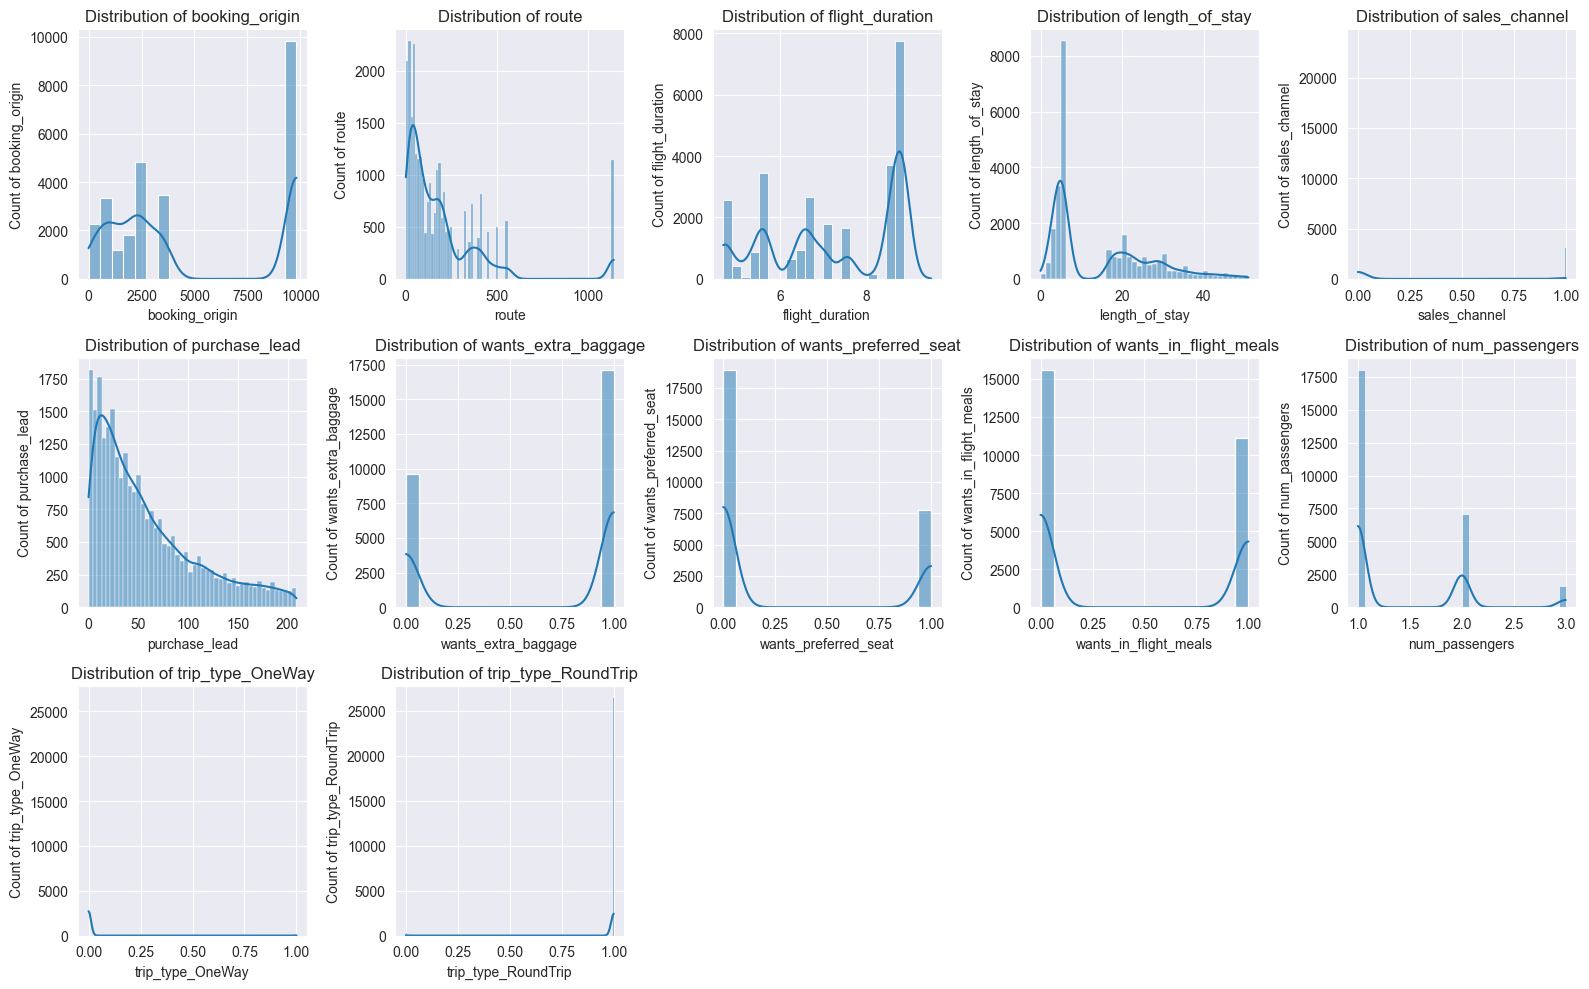

In [28]:
# Check distribution before scaling
plot_dynamic_hisplots_kdeplots(df=X_train_selected, col_series=selected_cols, ncols=5, figsize=(16, 10))

In [29]:
from utils import feature_scaling

# Define scaling configuration
scaling_config = {
    "robust": {
        # Right-skewed distributions with outliers — RobustScaler uses IQR, outlier-resistant
        "columns": [
            "booking_origin",   # Right-skewed, heavy spike at max end
            "route",            # Exponential decay, long right tail
            "flight_duration",  # Multi-modal, irregular peaks
            "length_of_stay",   # Right-skewed, visible outliers at high values
            "purchase_lead",    # Exponential decay, strong right skew
        ]
    },
    "minmax": {
        # Bounded / small discrete ranges — safe to scale to [0, 1]
        "columns": [
            "sales_channel",    # Already bounded [0, 1], bimodal
            "num_passengers",   # Discrete, small known range [1, 2, 3]
        ]
    },
    # Skipped — binary or one-hot encoded (no scaling needed):
    # wants_extra_baggage, wants_preferred_seat, wants_in_flight_meals
    # trip_type_OneWay, trip_type_RoundTrip
}

# FIT scaler on TRAINING data only
X_train_scaled, scaler = feature_scaling(
    data=X_train_selected.copy(),
    scaling_config=scaling_config
)

# TRANSFORM validation data using fitted scaler
X_val_scaled, _ = feature_scaling(
    data=X_val_selected.copy(),
    scaling_config=scaling_config,
    scaler=scaler
)

# TRANSFORM test data using fitted scaler
X_test_scaled, _ = feature_scaling(
    data=X_test_selected.copy(),
    scaling_config=scaling_config,
    scaler=scaler
)

print(f"Training set:   {X_train_scaled.shape[0]} samples ({X_train_scaled.shape[0]/total_samples*100:.1f}%)")
print(f"Validation set: {X_val_scaled.shape[0]} samples ({X_val_scaled.shape[0]/total_samples*100:.1f}%)")
print(f"Test set:       {X_test_scaled.shape[0]} samples ({X_test_scaled.shape[0]/total_samples*100:.1f}%)")

Training set:   26729 samples (54.2%)
Validation set: 7181 samples (14.6%)
Test set:       2465 samples (5.0%)


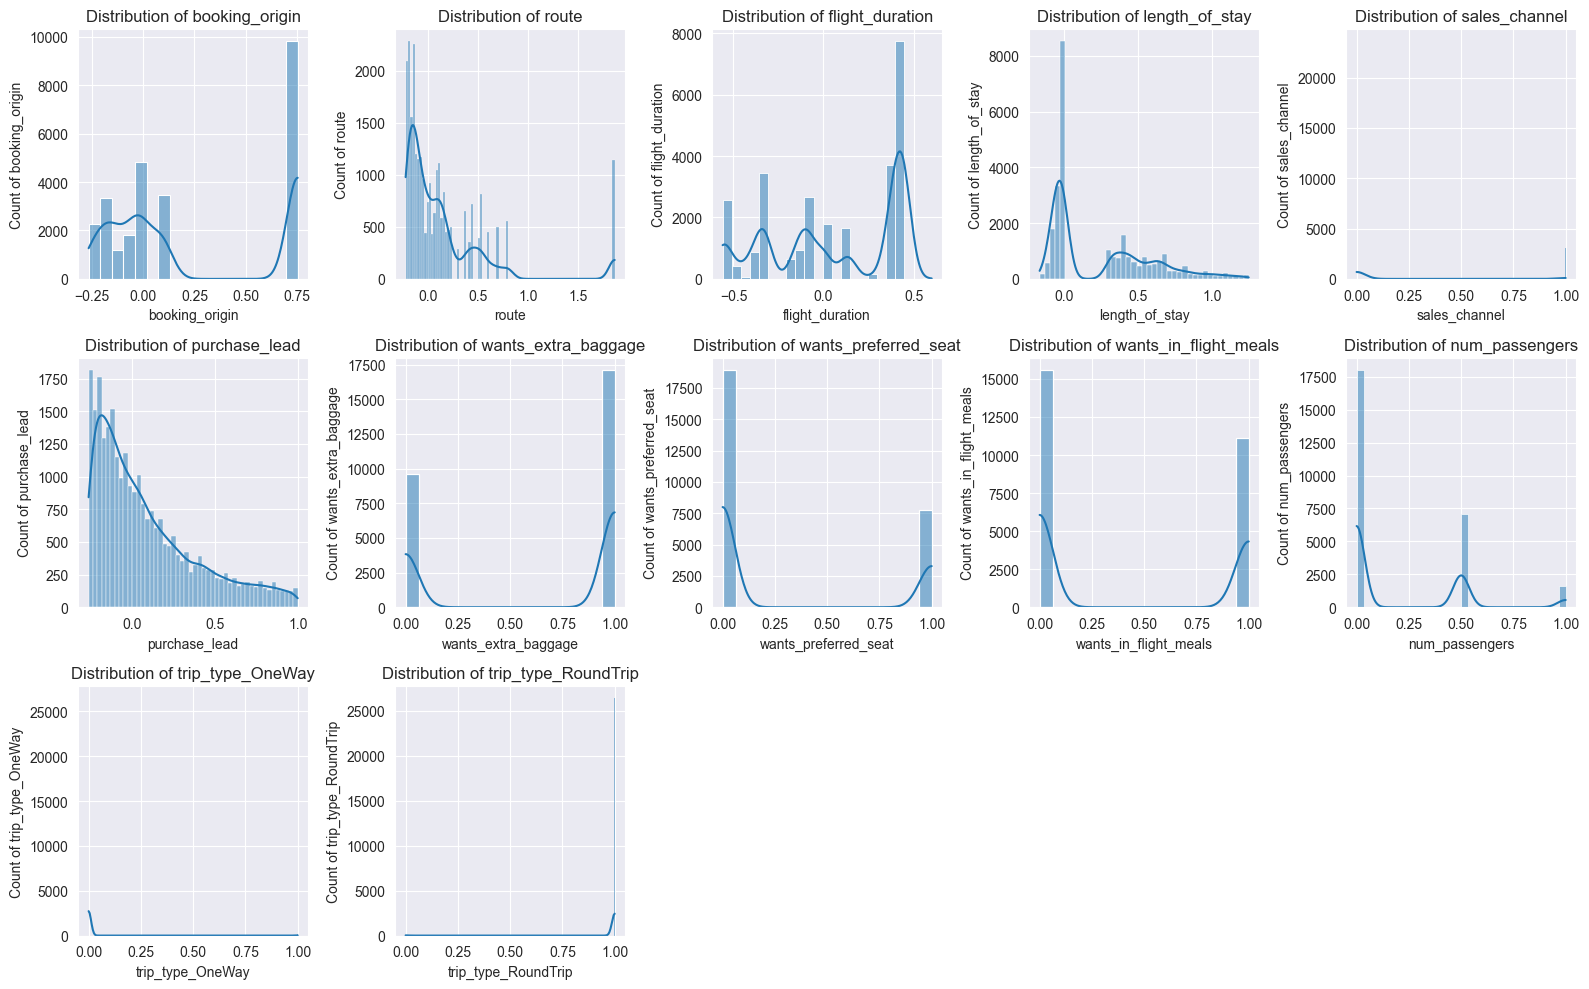

In [30]:
# Check distribution after scaling
plot_dynamic_hisplots_kdeplots(df=X_train_scaled, col_series=selected_cols, ncols=5, figsize=(16, 10))

## Handling Class Imbalance (Training Set Only)

In [31]:
from imblearn.over_sampling import SMOTE

# Check class distribution before SMOTE
print("Class distribution before SMOTE:")
print(y_train_clean.value_counts(normalize=True))

# Apply SMOTE to training data only
smote = SMOTE(sampling_strategy=0.8, random_state=42)  # 0.8 = 4:5 ratio
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_scaled, y_train_clean)

print(f"\nClass distribution after SMOTE:")
print(pd.Series(y_train_balanced).value_counts(normalize=True))
print(f"\nTraining samples after SMOTE: {len(X_train_balanced):,}")

Class distribution before SMOTE:
booking_complete
0    0.848853
1    0.151147
Name: proportion, dtype: float64

Class distribution after SMOTE:
booking_complete
0    0.555558
1    0.444442
Name: proportion, dtype: float64

Training samples after SMOTE: 40,840


In [65]:
# Save PREPROCESSED test data (for model evaluation)
# This is what the model sees during inference
df_test_preprocessed = pd.concat([X_test_scaled.reset_index(drop=True), y_test_raw.reset_index(drop=True)], axis=1)
df_test_preprocessed.to_csv('data/test_data_5%_preprocessed.csv', index=False)
print(f"Preprocessed test data saved to: data/test_data_5%_preprocessed.csv")
print(f"Shape: {df_test_preprocessed.shape}")

Preprocessed test data saved to: data/test_data_5%_preprocessed.csv
Shape: (2465, 13)


# **STAGE 4: MODELING**

## Model Training

In [32]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from xgboost import XGBClassifier

# Define baseline models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'KNN': KNeighborsClassifier(),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'AdaBoost': AdaBoostClassifier(random_state=42),
    'XGBoost': XGBClassifier(random_state=42)
}

# Train all baseline models
baseline_models = {}
for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train_balanced, y_train_balanced)
    baseline_models[name] = model
    
print("\nAll models trained successfully!")

Training Logistic Regression...
Training KNN...
Training Decision Tree...
Training Random Forest...
Training AdaBoost...
Training XGBoost...

All models trained successfully!


## Model Evaluation


Evaluating: Logistic Regression
Performance Metrics for LogisticRegression:

Cross-Validated Metrics (mean ± std):

ACCURACY:
  Test:  64.46 ± 0.53
  Train: 64.51 ± 0.12

PRECISION:
  Test:  59.80 ± 0.61
  Train: 59.85 ± 0.13

RECALL:
  Test:  61.13 ± 0.73
  Train: 61.19 ± 0.28

F1:
  Test:  60.46 ± 0.60
  Train: 60.51 ± 0.18

ROC_AUC:
  Test:  70.60 ± 0.51
  Train: 70.64 ± 0.13

Single Run Metrics:

ACCURACY:
  Test:  65.78
  Train: 64.50

PRECISION:
  Test:  24.46
  Train: 59.84

RECALL:
  Test:  59.54
  Train: 61.20

F1:
  Test:  34.67
  Train: 60.51

ROC_AUC:
  Test:  70.12
  Train: 70.64


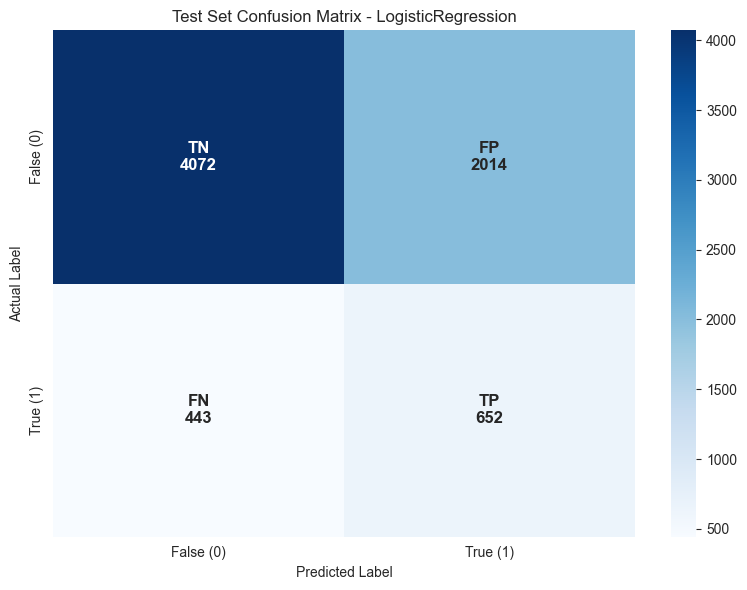

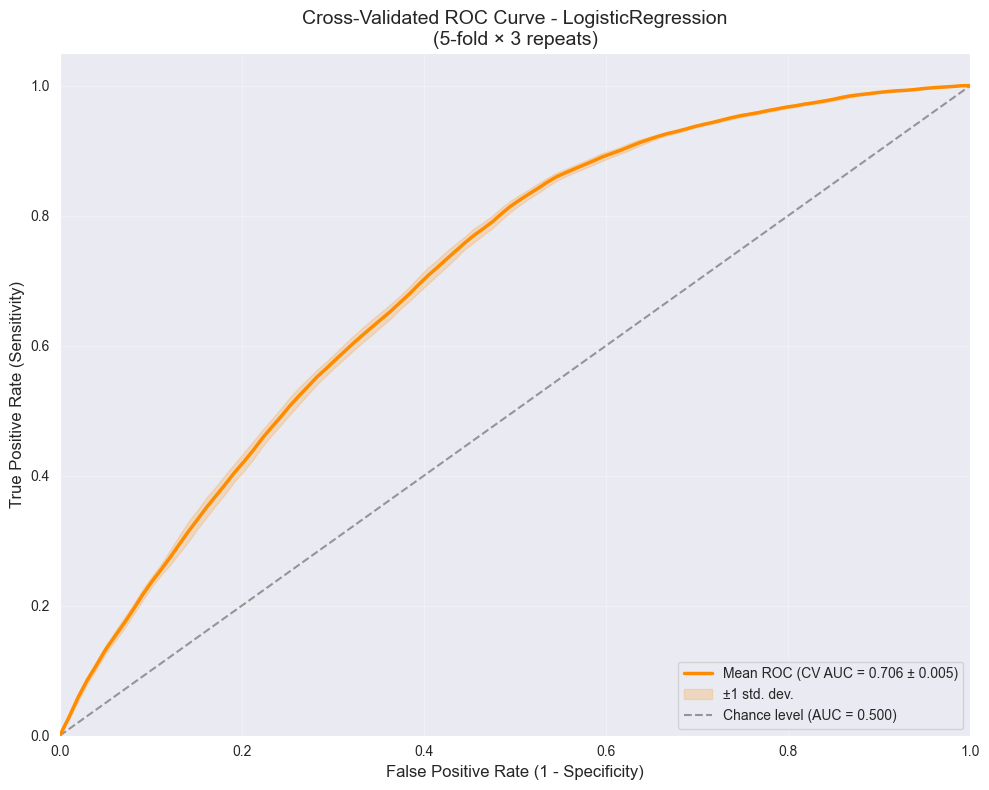


Evaluating: KNN
Performance Metrics for KNeighborsClassifier:

Cross-Validated Metrics (mean ± std):

ACCURACY:
  Test:  78.64 ± 0.43
  Train: 86.08 ± 0.13

PRECISION:
  Test:  71.36 ± 0.49
  Train: 79.15 ± 0.17

RECALL:
  Test:  86.78 ± 0.45
  Train: 93.26 ± 0.15

F1:
  Test:  78.32 ± 0.40
  Train: 85.63 ± 0.13

ROC_AUC:
  Test:  86.96 ± 0.41
  Train: 95.17 ± 0.06

Single Run Metrics:

ACCURACY:
  Test:  69.59
  Train: 87.05

PRECISION:
  Test:  24.73
  Train: 79.94

RECALL:
  Test:  48.68
  Train: 94.60

F1:
  Test:  32.80
  Train: 86.65

ROC_AUC:
  Test:  65.47
  Train: 96.00


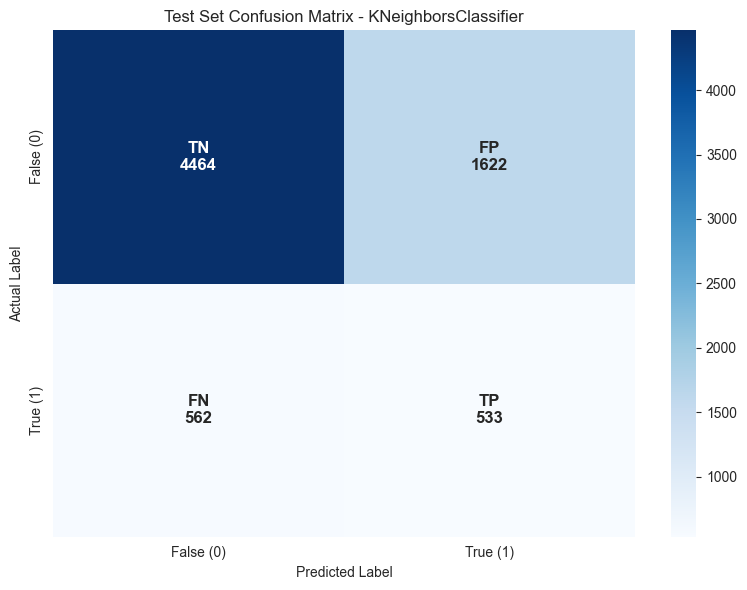

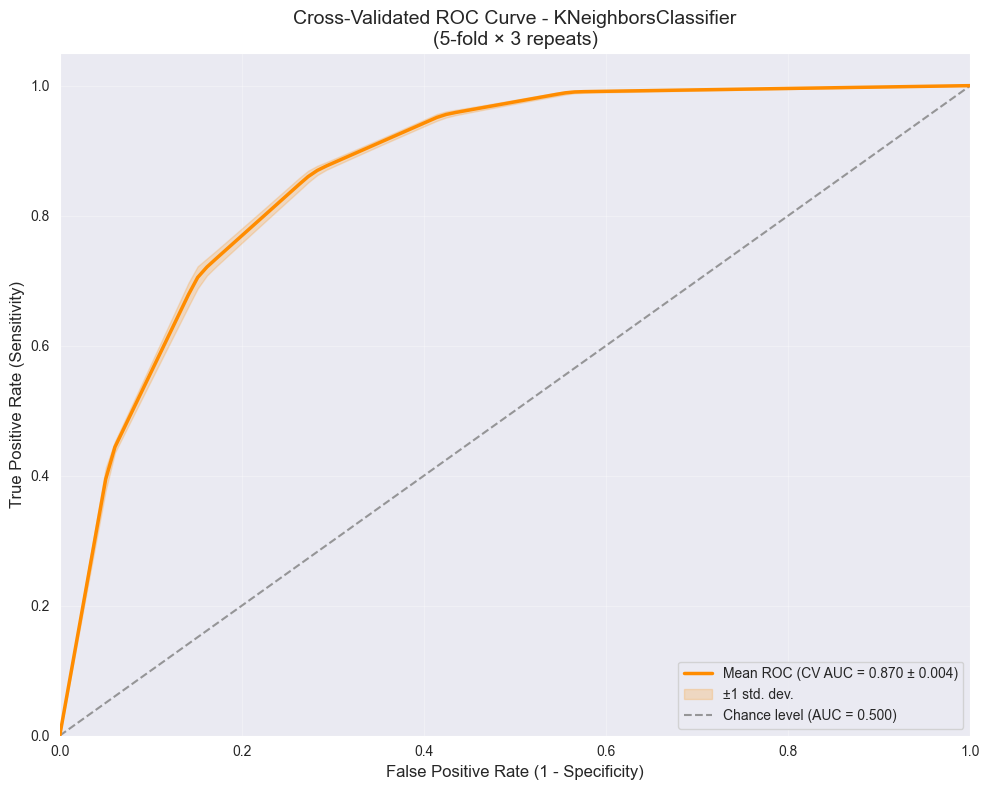


Evaluating: Decision Tree
Performance Metrics for DecisionTreeClassifier:

Cross-Validated Metrics (mean ± std):

ACCURACY:
  Test:  82.92 ± 0.39
  Train: 99.92 ± 0.01

PRECISION:
  Test:  80.29 ± 0.55
  Train: 99.99 ± 0.00

RECALL:
  Test:  81.62 ± 0.60
  Train: 99.83 ± 0.03

F1:
  Test:  80.95 ± 0.43
  Train: 99.91 ± 0.02

ROC_AUC:
  Test:  82.83 ± 0.40
  Train: 100.00 ± 0.00

Single Run Metrics:

ACCURACY:
  Test:  76.65
  Train: 99.90

PRECISION:
  Test:  28.19
  Train: 99.99

RECALL:
  Test:  34.34
  Train: 99.79

F1:
  Test:  30.96
  Train: 99.89

ROC_AUC:
  Test:  59.30
  Train: 100.00


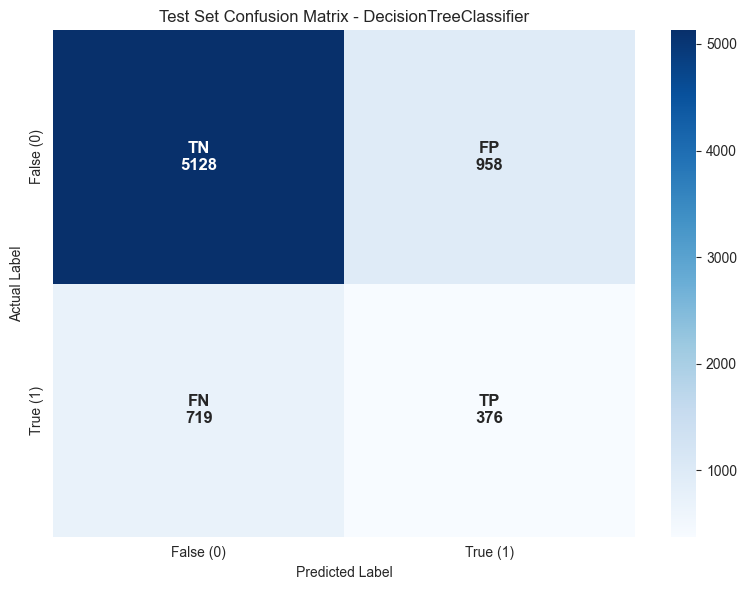

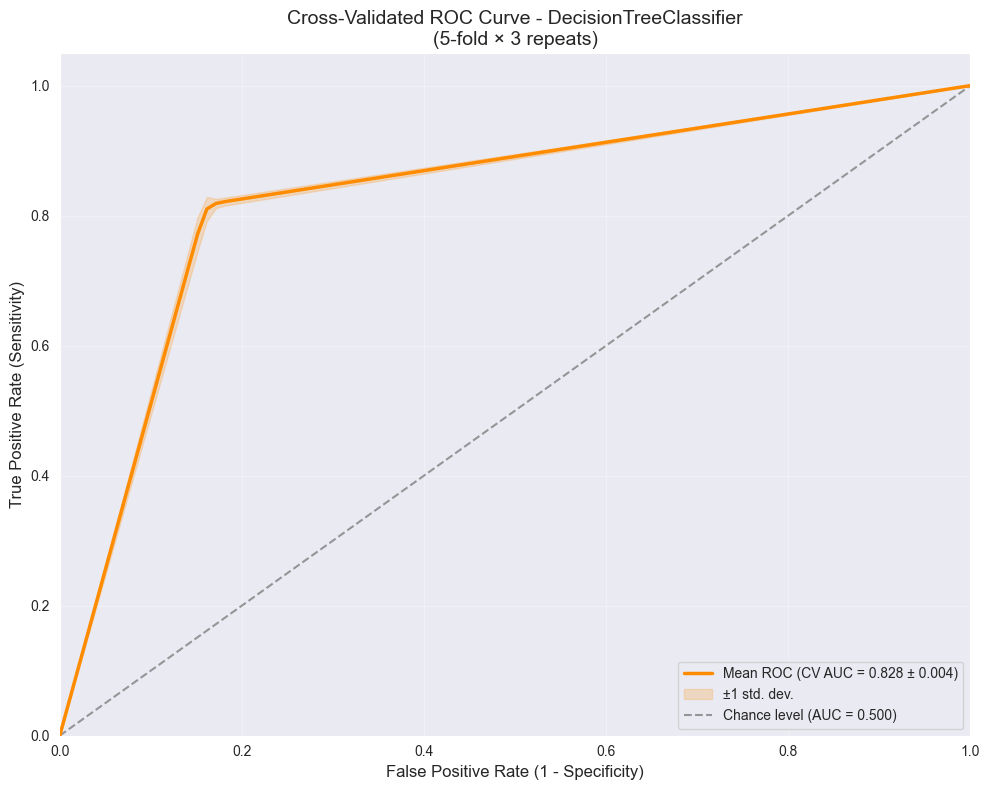


Evaluating: Random Forest
Performance Metrics for RandomForestClassifier:

Cross-Validated Metrics (mean ± std):

ACCURACY:
  Test:  88.56 ± 0.37
  Train: 99.92 ± 0.01

PRECISION:
  Test:  89.49 ± 0.54
  Train: 99.90 ± 0.02

RECALL:
  Test:  84.14 ± 0.56
  Train: 99.92 ± 0.02

F1:
  Test:  86.73 ± 0.43
  Train: 99.91 ± 0.02

ROC_AUC:
  Test:  95.00 ± 0.19
  Train: 100.00 ± 0.00

Single Run Metrics:

ACCURACY:
  Test:  82.26
  Train: 99.90

PRECISION:
  Test:  38.27
  Train: 99.90

RECALL:
  Test:  26.67
  Train: 99.87

F1:
  Test:  31.43
  Train: 99.89

ROC_AUC:
  Test:  74.19
  Train: 100.00


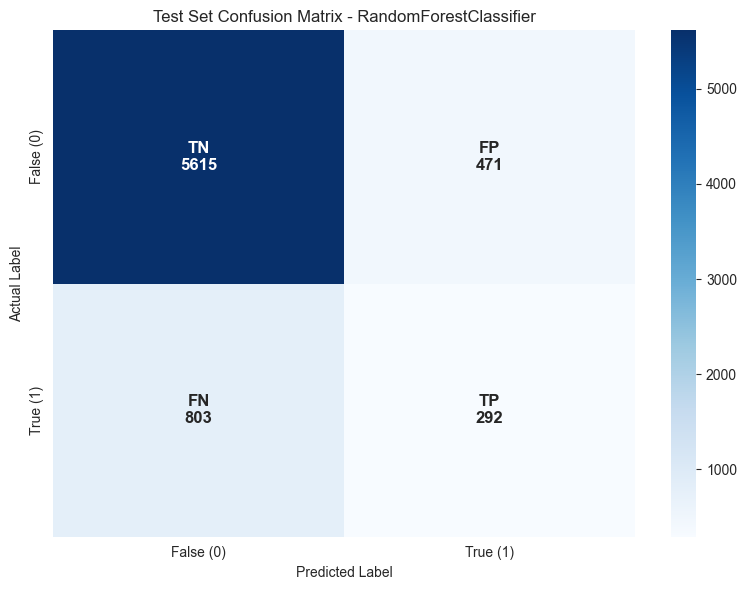

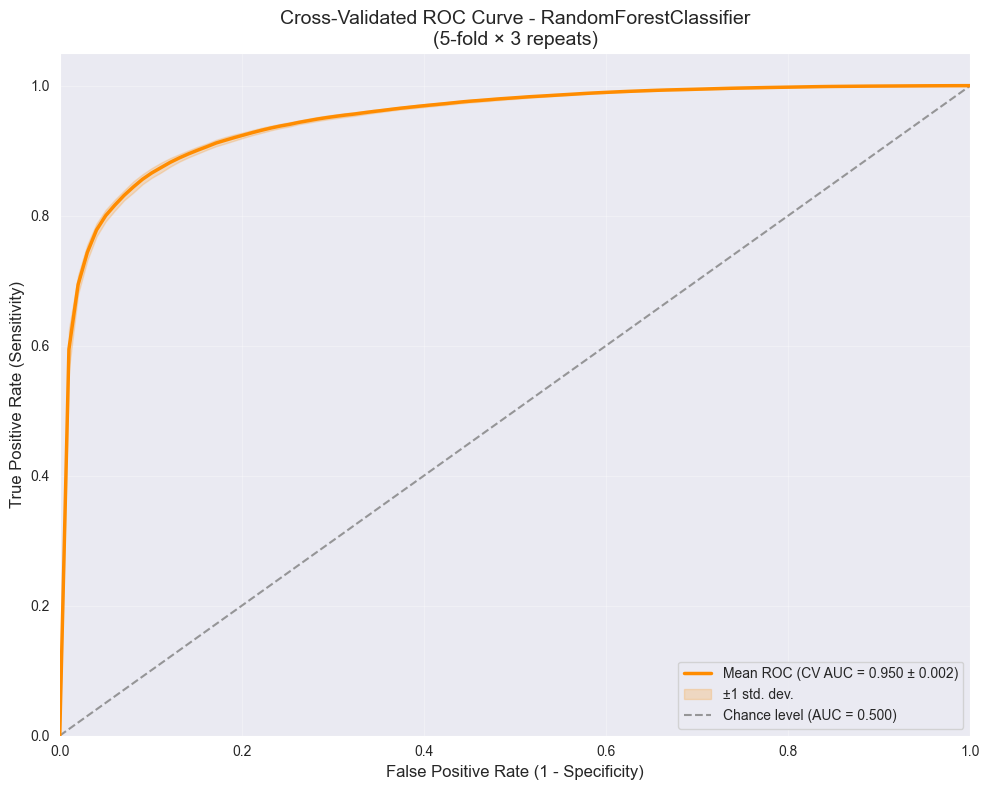


Evaluating: AdaBoost
Performance Metrics for AdaBoostClassifier:

Cross-Validated Metrics (mean ± std):

ACCURACY:
  Test:  74.07 ± 0.56
  Train: 74.28 ± 0.46

PRECISION:
  Test:  71.96 ± 1.67
  Train: 72.20 ± 1.63

RECALL:
  Test:  68.45 ± 2.68
  Train: 68.71 ± 2.67

F1:
  Test:  70.10 ± 0.89
  Train: 70.35 ± 0.81

ROC_AUC:
  Test:  82.03 ± 0.34
  Train: 82.23 ± 0.32

Single Run Metrics:

ACCURACY:
  Test:  74.54
  Train: 74.58

PRECISION:
  Test:  31.08
  Train: 71.75

RECALL:
  Test:  54.98
  Train: 70.62

F1:
  Test:  39.71
  Train: 71.18

ROC_AUC:
  Test:  74.01
  Train: 82.65


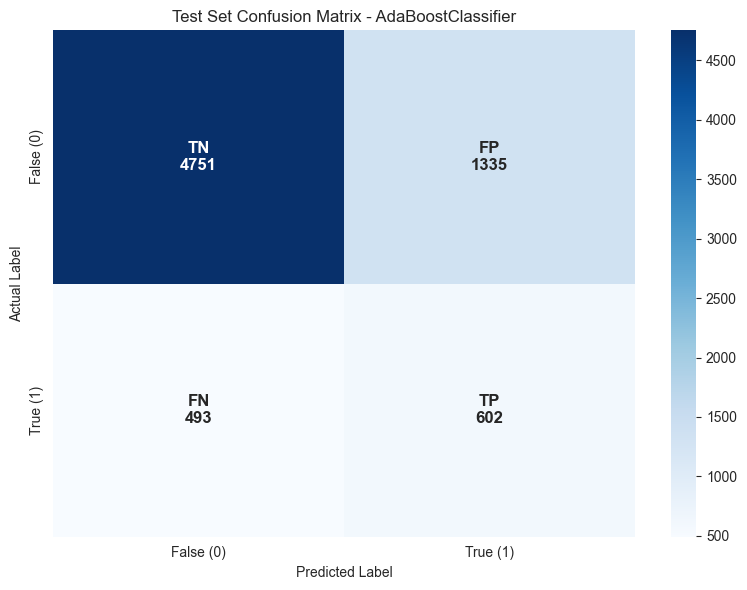

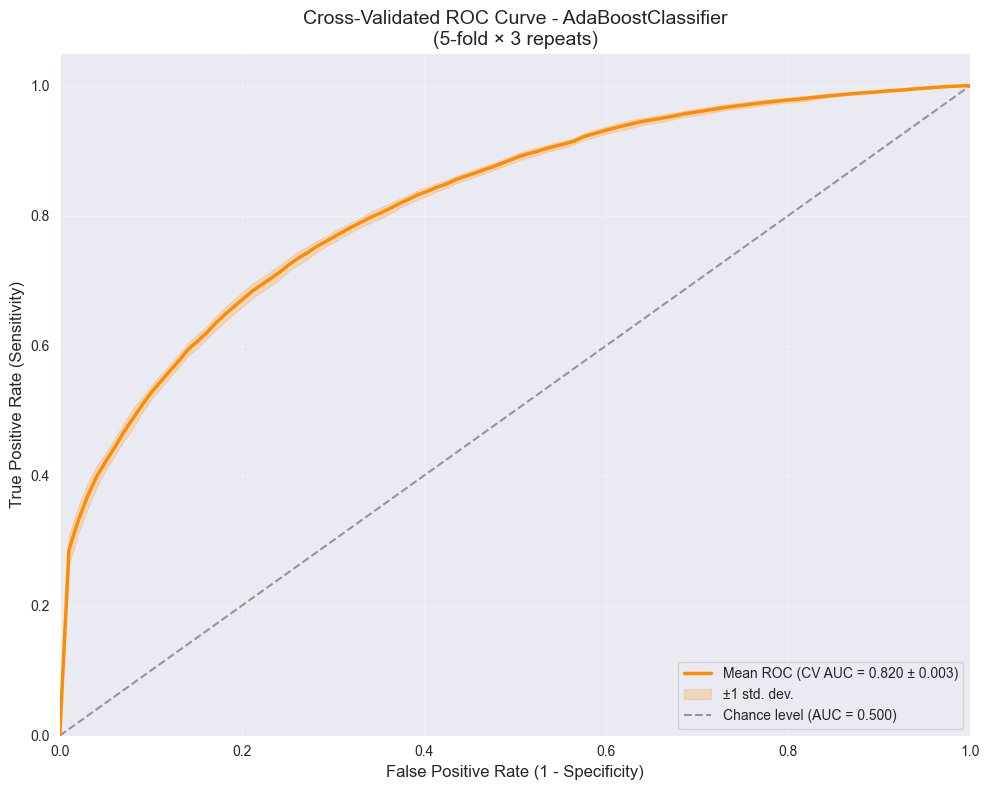


Evaluating: XGBoost
Performance Metrics for XGBClassifier:

Cross-Validated Metrics (mean ± std):

ACCURACY:
  Test:  86.98 ± 0.35
  Train: 90.38 ± 0.15

PRECISION:
  Test:  90.18 ± 0.42
  Train: 93.85 ± 0.18

RECALL:
  Test:  79.35 ± 0.70
  Train: 83.85 ± 0.25

F1:
  Test:  84.42 ± 0.45
  Train: 88.57 ± 0.18

ROC_AUC:
  Test:  94.03 ± 0.26
  Train: 96.94 ± 0.06

Single Run Metrics:

ACCURACY:
  Test:  83.22
  Train: 90.15

PRECISION:
  Test:  41.91
  Train: 94.04

RECALL:
  Test:  26.03
  Train: 83.12

F1:
  Test:  32.11
  Train: 88.24

ROC_AUC:
  Test:  76.55
  Train: 96.77


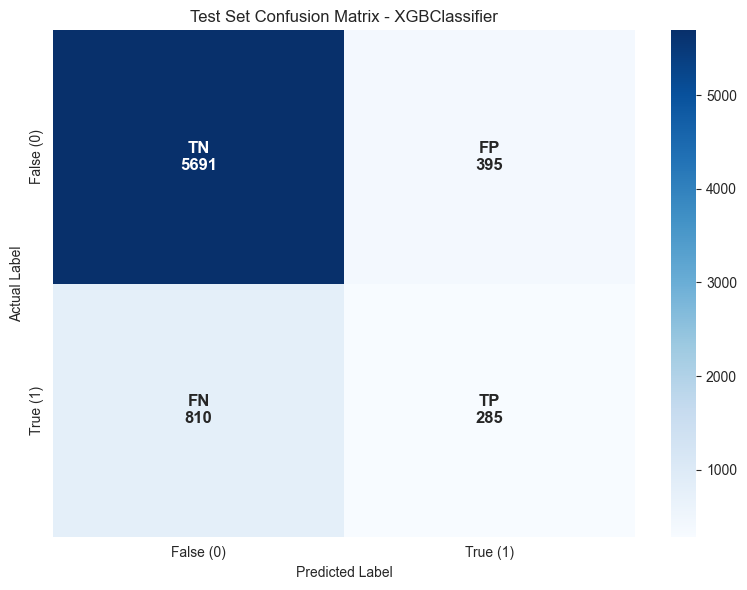

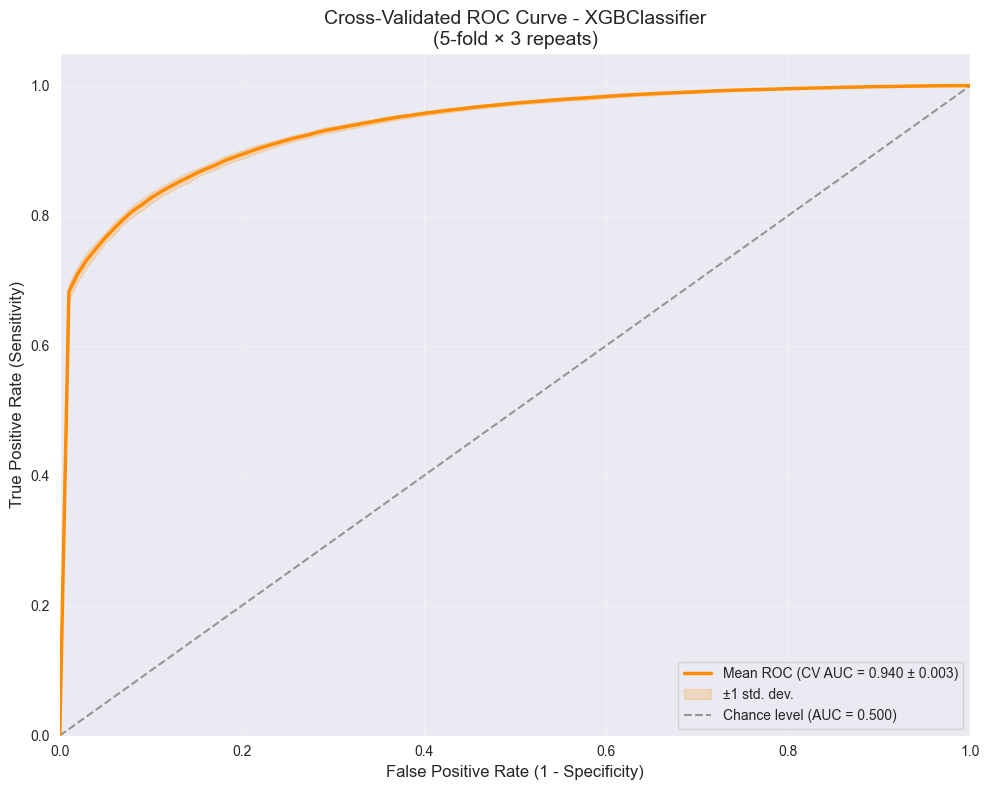

In [33]:
# Import classification evaluation and tuning utilities
from utils import eval_classification

# Evaluate each baseline model on validation set
baseline_metrics = {}

for name, model in baseline_models.items():
    print(f"\n{'='*60}")
    print(f"Evaluating: {name}")
    print('='*60)
    
    metrics = eval_classification(
        model=model,
        X_train=X_train_balanced,
        y_train=y_train_balanced,
        X_test=X_val_scaled,
        y_test=y_val_clean,
        plot_confusion_matrix=True,
        plot_roc_curve=True,
        plot_pr_curve=False,
        plot_calibration_curve=False,
        plot_threshold_analysis=False,
    )
    
    baseline_metrics[name] = metrics

In [35]:
# Compare all baseline models
from utils import compare_cv_metrics_classification

comparison_df = compare_cv_metrics_classification(baseline_metrics)
print("\n=== BASELINE MODEL COMPARISON (Cross-Validation) ===\n")
display(comparison_df)


=== BASELINE MODEL COMPARISON (Cross-Validation) ===



,Model,ACCURACY,PRECISION,RECALL,F1,ROC_AUC
0,Logistic Regression,64.46% ± 0.53%,59.80% ± 0.61%,61.13% ± 0.73%,60.46% ± 0.60%,70.60% ± 0.51%
1,KNN,78.64% ± 0.43%,71.36% ± 0.49%,86.78% ± 0.45%,78.32% ± 0.40%,86.96% ± 0.41%
2,Decision Tree,82.92% ± 0.39%,80.29% ± 0.55%,81.62% ± 0.60%,80.95% ± 0.43%,82.83% ± 0.40%
3,Random Forest,88.56% ± 0.37%,89.49% ± 0.54%,84.14% ± 0.56%,86.73% ± 0.43%,95.00% ± 0.19%
4,AdaBoost,74.07% ± 0.56%,71.96% ± 1.67%,68.45% ± 2.68%,70.10% ± 0.89%,82.03% ± 0.34%
5,XGBoost,86.98% ± 0.35%,90.18% ± 0.42%,79.35% ± 0.70%,84.42% ± 0.45%,94.03% ± 0.26%


In [36]:
# Find the best model for each metric
metrics_list = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
best_models = {}

for metric in metrics_list:
    best_score = 0
    best_name = None
    
    for name, metrics in baseline_metrics.items():
        if 'cv' in metrics and metric in metrics['cv']:
            score = metrics['cv'][metric]['test_mean']
            if score > best_score:
                best_score = score
                best_name = name
    
    best_models[metric] = {'model_name': best_name, 'score': best_score}

# Calculate average score across all metrics for each model (best overall)
model_avg_scores = {}
for name, metrics in baseline_metrics.items():
    if 'cv' in metrics:
        scores = []
        for metric in metrics_list:
            if metric in metrics['cv']:
                scores.append(metrics['cv'][metric]['test_mean'])
        if scores:
            model_avg_scores[name] = sum(scores) / len(scores)

# Find best overall model
best_overall_name = max(model_avg_scores, key=model_avg_scores.get)
best_overall_avg = model_avg_scores[best_overall_name]

print("=== Best Model for Each Metric ===\n")
for metric, info in best_models.items():
    print(f"★ {metric.upper():12s}: {info['model_name']} ({info['score']*100:.2f}%)")

print("\n=== Average Scores Across All Metrics ===\n")
for name, avg_score in sorted(model_avg_scores.items(), key=lambda x: x[1], reverse=True):
    marker = "★" if name == best_overall_name else " "
    print(f"{marker} {name:25s}: {avg_score*100:.2f}%")

print(f"\n→ Best Overall Model: {best_overall_name} (avg = {best_overall_avg*100:.2f}%)")

=== Best Model for Each Metric ===

★ ACCURACY    : Random Forest (88.56%)
★ PRECISION   : XGBoost (90.18%)
★ RECALL      : KNN (86.78%)
★ F1          : Random Forest (86.73%)
★ ROC_AUC     : Random Forest (95.00%)

=== Average Scores Across All Metrics ===

★ Random Forest            : 88.78%
  XGBoost                  : 86.99%
  Decision Tree            : 81.72%
  KNN                      : 80.41%
  AdaBoost                 : 73.32%
  Logistic Regression      : 63.29%

→ Best Overall Model: Random Forest (avg = 88.78%)


## (Optional) Hyperparamaeter Tuning

In [38]:
# # Hyperparameter tuning for best model
# from utils import tune_single_model_classification

# best_model_name = "Random Forest" # the method to extract this can be from previous code cell instead of hard-coded
# model_key_map = {
#     'Logistic Regression': 'logisticregression',
#     'K-Nearest Neighbors': 'knn',
#     'Decision Tree': 'decisiontree',
#     'Random Forest': 'randomforest',
#     'Gradient Boosting': 'gb',
#     'XGBoost': 'xgboost',
# }

# best_model_key = model_key_map[best_model_name]

# print(f"Tuning {best_model_name}...")

# rf_tuned, fit_time = tune_single_model_classification(
#     model_name=best_model_key,
#     X_train=X_train_balanced,
#     y_train=y_train_balanced,
#     X_test=X_val_scaled,
#     y_test=y_val_clean,
#     search_method='grid',
#     scoring='recall',
#     display=True,
#     progress_bar=True,
#     plot_validation_curves=True,
#     plot_learning_curves=True
# )

# print(f"\n✓ Tuning complete!")
# print(f'Best CV Score: {rf_tuned.best_score_:.4f}')
# print(f'Best Parameters: {rf_tuned.best_params_}')

In [ ]:
# # Train final model with tuned hyperparameters (optional for direct run without running the whole notebook)
# from sklearn.ensemble import RandomForestClassifier

# rf_tuned_direct = RandomForestClassifier(
#     random_state=42,
#     n_estimators=50,
#     criterion='gini',
#     max_depth=10, 
#     max_features='sqrt', 
#     min_samples_leaf=4, 
#     min_samples_split=10, 
# )
# rf_tuned_direct.fit(X_train_scaled, y_train_clean)

In [ ]:
# # Evaluate tuned model
# from utils import eval_classification

# tuned_metrics = eval_classification(
#     model=rf_tuned_direct,
#     X_train=X_train_balanced,
#     y_train=y_train_clean,
#     X_test=X_val_scaled,
#     y_test=y_val_clean,
#     plot_confusion_matrix=True,
#     plot_roc_curve=True,
#     plot_pr_curve=False,
#     plot_calibration_curve=False,
#     plot_threshold_analysis=False,
# )

## Feature Importance

## 1. Random Forest Feature Importance (Gini-based)

**Method:** Measures average impurity reduction across all trees when splitting on each feature.

**Pros:** Fast, built-in, captures feature usage in tree structure

**Cons:** Biased toward high-cardinality features, doesn't account for feature interactions


FEATURE IMPORTANCE (GINI-BASED)

Top 15 Most Important Features:


,Feature,Importance
0,length_of_stay,0.209413
1,booking_origin,0.207769
2,purchase_lead,0.186956
3,route,0.160295
4,flight_duration,0.133429
5,num_passengers,0.034373
6,wants_in_flight_meals,0.018675
7,wants_extra_baggage,0.016518
8,wants_preferred_seat,0.016316
9,sales_channel,0.013156


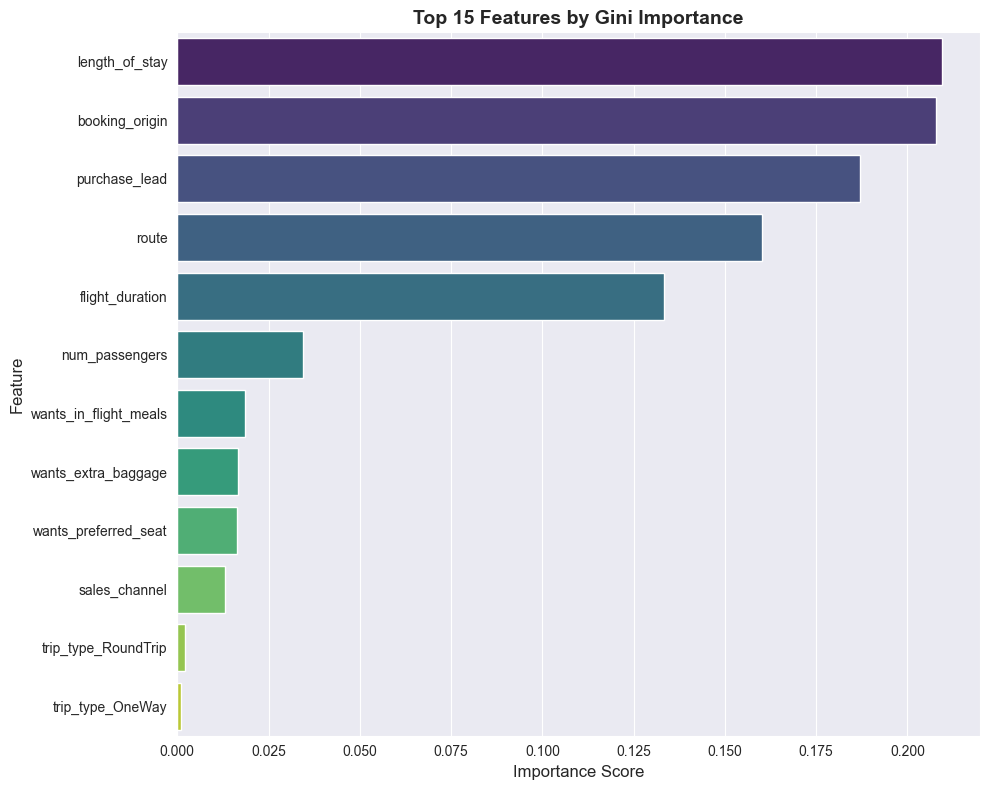


Total features: 12
Top 5 features contribute: 89.79% of total importance
Top 10 features contribute: 99.69% of total importance


In [47]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Extract feature importances from the trained model
feature_importance_gini = pd.DataFrame({
    'Feature': X_train_balanced.columns,
    'Importance': baseline_models[best_model_name].feature_importances_
}).sort_values('Importance', ascending=False)

# Display top features
print("\n" + "="*60)
print("FEATURE IMPORTANCE (GINI-BASED)")
print("="*60)
print("\nTop 15 Most Important Features:")
display(feature_importance_gini.head(15).reset_index(drop=True))

# Visualize
plt.figure(figsize=(10, 8))
top_n = 15
sns.barplot(
    data=feature_importance_gini.head(top_n),
    x='Importance',
    y='Feature',
    palette='viridis'
)
plt.title(f'Top {top_n} Features by Gini Importance', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.tight_layout()
plt.show()

# Summary statistics
print(f"\nTotal features: {len(feature_importance_gini)}")
print(f"Top 5 features contribute: {feature_importance_gini.head(5)['Importance'].sum():.2%} of total importance")
print(f"Top 10 features contribute: {feature_importance_gini.head(10)['Importance'].sum():.2%} of total importance")

## 2. Permutation Importance

**Method:** Shuffles each feature and measures the resulting drop in model performance (R²).

**Pros:** More reliable than Gini, works with any model, reflects actual prediction impact

**Cons:** Slower (requires multiple predictions), can be affected by correlated features

**Note:** We compute on validation set to avoid overfitting to training data patterns.


Computing permutation importance (this may take a minute)...

PERMUTATION IMPORTANCE (R² DECREASE)

Top 15 Most Important Features:


,Feature,Importance_Mean,Importance_Std
0,booking_origin,0.182430,0.023101
1,route,0.127259,0.020271
2,flight_duration,0.094825,0.018960
3,purchase_lead,0.035883,0.015459
4,length_of_stay,0.019719,0.015216
5,wants_preferred_seat,0.010021,0.007341
6,sales_channel,0.005603,0.005839
7,wants_in_flight_meals,0.000431,0.012212
8,trip_type_RoundTrip,-0.000539,0.001466
9,trip_type_OneWay,-0.000862,0.001346


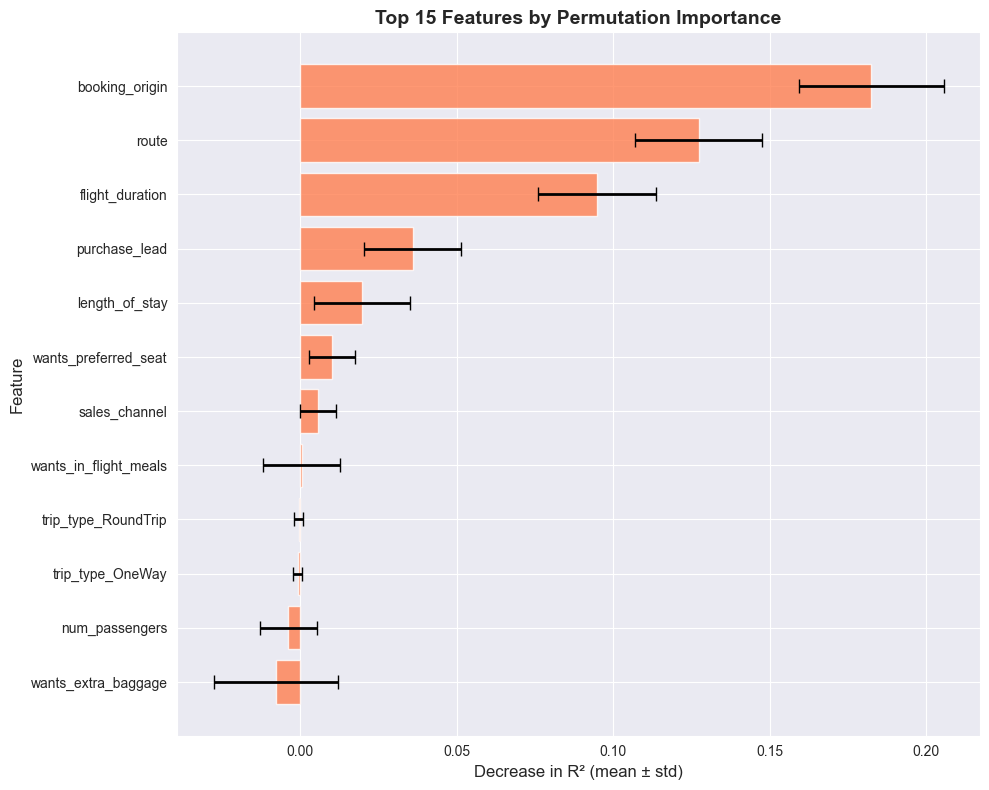


Interpretation: When we shuffle a feature's values, the model's R² drops by the importance score.
Higher drop = more important feature for predictions.


In [48]:
from sklearn.inspection import permutation_importance

print("\nComputing permutation importance (this may take a minute)...")

# Calculate permutation importance on VALIDATION set
perm_importance = permutation_importance(
    baseline_models[best_model_name],
    X_val_scaled,
    y_val_clean,
    n_repeats=10,
    random_state=42,
    scoring='r2',
    n_jobs=-1
)

# Create DataFrame with results
feature_importance_perm = pd.DataFrame({
    'Feature': X_train_balanced.columns,
    'Importance_Mean': perm_importance.importances_mean,
    'Importance_Std': perm_importance.importances_std
}).sort_values('Importance_Mean', ascending=False)

# Display results
print("\n" + "="*60)
print("PERMUTATION IMPORTANCE (R² DECREASE)")
print("="*60)
print("\nTop 15 Most Important Features:")
display(feature_importance_perm.head(15).reset_index(drop=True))

# Visualize with error bars
plt.figure(figsize=(10, 8))
top_n = 15
top_features = feature_importance_perm.head(top_n)

plt.barh(
    range(len(top_features)),
    top_features['Importance_Mean'],
    xerr=top_features['Importance_Std'],
    color='coral',
    alpha=0.8,
    error_kw={'linewidth': 2, 'ecolor': 'black', 'capsize': 5}
)
plt.yticks(range(len(top_features)), top_features['Feature'])
plt.xlabel('Decrease in R² (mean ± std)', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.title(f'Top {top_n} Features by Permutation Importance', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print(f"\nInterpretation: When we shuffle a feature's values, the model's R² drops by the importance score.")
print(f"Higher drop = more important feature for predictions.")

## Final Test Set Evaluation

FINAL TEST SET EVALUATION
Performance Metrics for RandomForestClassifier:

Cross-Validated Metrics (mean ± std):

ACCURACY:
  Test:  88.56 ± 0.37
  Train: 99.92 ± 0.01

PRECISION:
  Test:  89.49 ± 0.54
  Train: 99.90 ± 0.02

RECALL:
  Test:  84.14 ± 0.56
  Train: 99.92 ± 0.02

F1:
  Test:  86.73 ± 0.43
  Train: 99.91 ± 0.02

ROC_AUC:
  Test:  95.00 ± 0.19
  Train: 100.00 ± 0.00

Single Run Metrics:

ACCURACY:
  Test:  81.34
  Train: 99.90

PRECISION:
  Test:  31.09
  Train: 99.90

RECALL:
  Test:  20.00
  Train: 99.87

F1:
  Test:  24.34
  Train: 99.89

ROC_AUC:
  Test:  68.78
  Train: 100.00


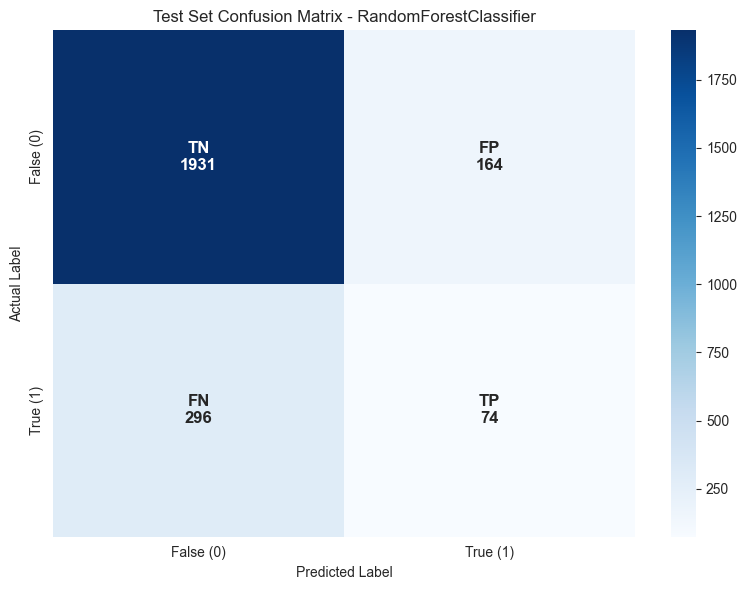

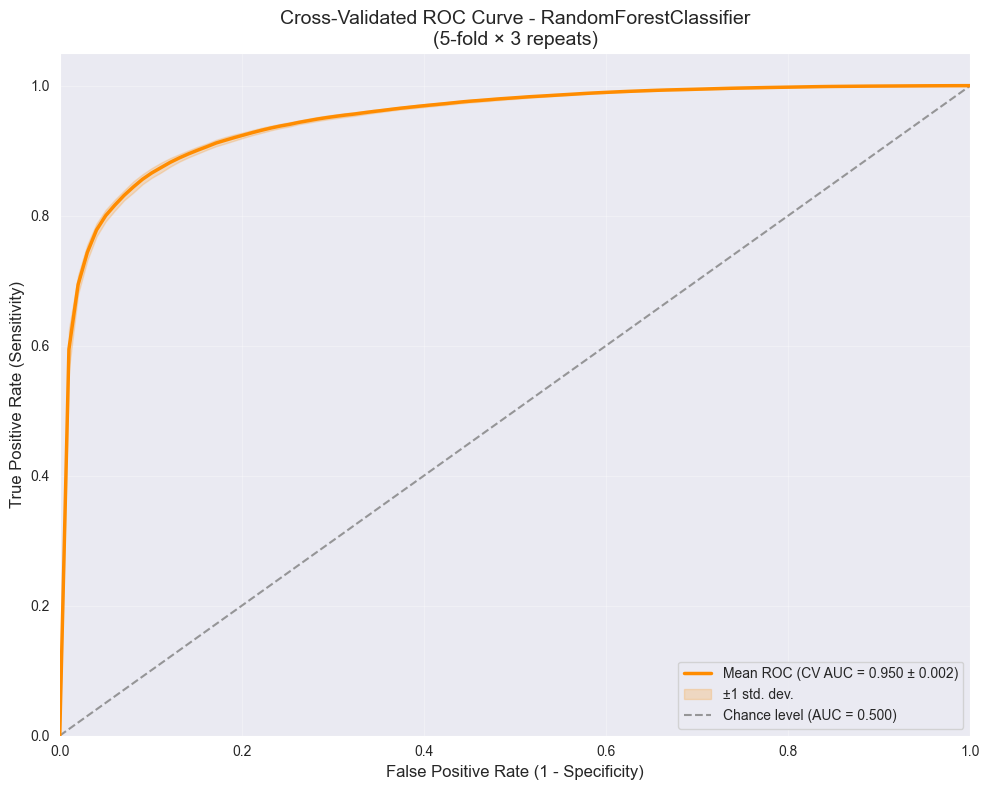


These are the final, unbiased performance metrics.


In [53]:
# Final evaluation on TEST set
print("=" * 60)
print("FINAL TEST SET EVALUATION")
print("=" * 60)

metrics_test = eval_classification(
    model=baseline_models[best_model_name],
    X_train=X_train_balanced,
    y_train=y_train_balanced,
    X_test=X_test_scaled,
    y_test=y_test_raw,
    plot_confusion_matrix=True,
    plot_roc_curve=True,
    plot_pr_curve=False,
    plot_calibration_curve=False,
    plot_threshold_analysis=False,
)

print("\n" + "=" * 60)
print("These are the final, unbiased performance metrics.")
print("=" * 60)

## Save Model and Artifacts

In [63]:
# Re-checks artifacts to save

print(baseline_models[best_model_name])
print(scaler)
print(encoders)

RandomForestClassifier(random_state=42)
{'robust': RobustScaler(quantile_range=(5, 95)), 'minmax': MinMaxScaler()}
{'binary_sales_channel': {'mapping': {'Internet': 0, 'Mobile': 1}, 'sorted_values': ['Internet', 'Mobile']}, 'onehot_trip_type': OneHotEncoder(drop='first', sparse_output=False), 'onehot_flight_day': OneHotEncoder(drop='first', sparse_output=False), 'frequency_route': CountEncoder(cols=['route'], combine_min_nan_groups=True), 'frequency_booking_origin': CountEncoder(cols=['booking_origin'], combine_min_nan_groups=True)}


In [58]:
import joblib

# Save the best model
joblib.dump(baseline_models[best_model_name], 'models/random_forest_model.joblib')
joblib.dump(scaler, 'models/scalers.joblib')
joblib.dump(encoders, 'models/encoders.joblib')

print("Model and preprocessing artifacts saved successfully!")
print(f"\nSaved files:")
print("- random_forest_model.joblib")
print("- scalers.joblib")
print("- encoders.joblib")

Model and preprocessing artifacts saved successfully!

Saved files:
- random_forest_model.joblib
- scalers.joblib
- encoders.joblib
